# Base pseudo-code

In [35]:
import torch
from torch import nn, optim

def forsaken(f_theta_0, T, lambda_, omega, P, D_f, eta_mu, xi):
    model_t = f_theta_0
    theta_0 = [param.clone().detach() for param in f_theta_0.parameters()]
    mu = [torch.zeros_like(param, requires_grad=True) for param in theta_0]
    criterion = nn.KLDivLoss()
    optimizer = optim.LBFGS(mu, lr=eta_mu)

    for _ in range(T):
        with torch.no_grad():
            for param, theta, m in zip(model_t.parameters(), theta_0, mu):
                param.copy_((theta - xi * m).detach())

        upsilon = model_t(D_f)
        loss = criterion(upsilon, P) + lambda_ * omega * sum(torch.norm(m, p=1) for m in mu)

        loss.backward()
        optimizer.step()

    return model_t



# Code

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import random
import copy
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import Subset, DataLoader, TensorDataset, ConcatDataset, random_split
from torch.nn.utils.stateless import functional_call

import torchvision
import torchvision.transforms as transforms

In [2]:
# ---- Transform ----
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# ---- Load datasets ----
train_dataset_full = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
test_dataset_full = datasets.MNIST(root="./data", train=False, transform=transform, download=True)

# ---- Forget Set ID----
def create_train_set(dataset, num_forget=0):
    forget_indices = random.sample(range(len(dataset)), num_forget)  # Randomly sample forget data
    D_f = Subset(dataset, forget_indices)  # Forget Set
    D_rest_indices = list(set(range(len(dataset))) - set(forget_indices))  # Rest of the data
    D_rest = Subset(dataset, D_rest_indices)  # Remaining training data

    # DataLoaders for each set
    forget_loader = DataLoader(D_f, batch_size=num_forget, shuffle=False)  # DataLoader for forget set
    train_loader = DataLoader(D_rest, batch_size=64, shuffle=True)  # DataLoader for remaining training data
    full_loader = DataLoader(dataset, batch_size=64, shuffle=True)  # DataLoader for the full training dataset

    return full_loader, train_loader, forget_loader 

def create_train_set_gaussian(dataset, contamination_ratio, epsilon, subset_size=10000, plot_examples=False):
    # Limiter la taille du sous-ensemble
    raw_images = dataset.data[:subset_size].float() / 255.0
    raw_labels = dataset.targets[:subset_size]

    num_total = len(raw_images)
    num_contaminated = int(num_total * contamination_ratio)
    contaminated_indices = random.sample(range(num_total), num_contaminated)
    clean_indices = list(set(range(num_total)) - set(contaminated_indices))

    # Ajout du bruit gaussien
    def add_gaussian_noise(images, mean=0, std=0.2):
        noise = torch.randn_like(images) * std + mean
        noisy_images = torch.clamp(images + noise, 0.0, 1.0)
        return noisy_images, noise

    base_contaminated_images = raw_images[contaminated_indices]
    contaminated_images, noise = add_gaussian_noise(base_contaminated_images, epsilon * epsilon)

    clean_images = raw_images[clean_indices]

    # Normalisation
    #contaminated_images = (contaminated_images - 0.1307) / 0.3081
    #clean_images = (clean_images - 0.1307) / 0.3081
    #base_contaminated_images = (base_contaminated_images - 0.1307) / 0.3081
    #noise = noise / 0.3081  # Normaliser le bruit aussi pour qu'il corresponde aux images normalisées

    # Ajouter la dimension du canal
    contaminated_images = contaminated_images.unsqueeze(1)
    clean_images = clean_images.unsqueeze(1)
    base_contaminated_images = base_contaminated_images.unsqueeze(1)
    noise = noise.unsqueeze(1)

    # Concaténation des jeux de données
    train_images = torch.cat([clean_images, contaminated_images], dim=0)
    train_labels = torch.cat([raw_labels[clean_indices], raw_labels[contaminated_indices]], dim=0)

    # Datasets
    full_train_dataset = TensorDataset(train_images, train_labels)
    clean_train_dataset = TensorDataset(clean_images, raw_labels[clean_indices])
    contaminated_dataset = TensorDataset(contaminated_images, raw_labels[contaminated_indices])
    base_contaminated_dataset = TensorDataset(base_contaminated_images, raw_labels[contaminated_indices])
    noise_dataset = TensorDataset(noise, raw_labels[contaminated_indices])

    # Dataloaders
    full_loader = DataLoader(full_train_dataset, batch_size=64, shuffle=True)
    clean_loader = DataLoader(clean_train_dataset, batch_size=64, shuffle=True)
    contaminated_loader = DataLoader(contaminated_dataset, batch_size=num_contaminated, shuffle=False)
    base_contaminated_loader = DataLoader(base_contaminated_dataset, batch_size=1, shuffle=False)
    noise_loader = DataLoader(noise_dataset, batch_size=1, shuffle=False)

    if plot_examples:
        fig, axes = plt.subplots(1, 5, figsize=(10, 2))
        for i in range(5):
            axes[i].imshow(contaminated_images[i].squeeze(), cmap='gray')
            axes[i].set_title(f"Label: {raw_labels[contaminated_indices[i]].item()}")
            axes[i].axis('off')
        plt.suptitle("Exemples de données contaminées (bruit gaussien)")
        plt.show()

    return {
        "full_loader": full_loader,
        "clean_loader": clean_loader,
        "contaminated_loader": contaminated_loader,
        "base_contaminated_loader": base_contaminated_loader,
        "noise_loader": noise_loader
    }

# ---- Sample Set from Test Data ----
def create_test_set(dataset, subset_size=0, num_sample=0):
    
    sample_indices = random.sample(range(len(dataset)), num_sample)
    D_sample = Subset(dataset, sample_indices)
    D_test_rest_indices = list(set(range(len(dataset))) - set(sample_indices))
    D_test_rest = Subset(dataset, D_test_rest_indices)
    sample_loader = DataLoader(D_sample, batch_size=64, shuffle=False)
    test_loader = DataLoader(D_test_rest, batch_size=64, shuffle=False)
    return test_loader, sample_loader, sample_indices

# ---- Omega Set from Training Data ----
def create_omega_loader(dataset, proportion=0.01):
    num_omega = int(len(dataset) * proportion)
    omega_indices = random.sample(range(len(dataset)), num_omega)
    omega_subset = Subset(dataset, omega_indices)
    omega_loader = DataLoader(omega_subset, batch_size=1, shuffle=False, drop_last=False)
    return omega_loader, omega_indices

In [3]:
class FullyConnectedNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [4]:
def train_model(model, train_loader, lr, epochs):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01)
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for images, labels in train_loader:
            optimizer.zero_grad()
            output = model(images)
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}")

In [5]:
def compute_hessian_singular(model, images, labels, criterion):
    model.zero_grad()
    output = model(images)
    loss = criterion(output, labels)
    
    # Compute first-order gradients and track parameter shapes/sizes
    grad_params = torch.autograd.grad(loss, model.parameters(), create_graph=True)
    param_shapes = [p.shape for p in model.parameters()]
    param_sizes = [p.numel() for p in model.parameters()]
    
    # Flatten gradients and generate random vector
    flat_grad = torch.cat([g.view(-1) for g in grad_params])
    v = torch.randn_like(flat_grad)
    v = v / torch.norm(v)
    
    # Split flat vector `v` into parts matching parameter shapes
    v_split = []
    start = 0
    for size, shape in zip(param_sizes, param_shapes):
        end = start + size
        v_split.append(v[start:end].view(shape))
        start = end
    
    # Power iteration with split vectors
    for _ in range(3):
        hv = torch.autograd.grad(
            grad_params, 
            model.parameters(), 
            grad_outputs=v_split,  # Use split gradients
            retain_graph=True
        )
        # Flatten Hessian-vector product
        flat_hv = torch.cat([h.view(-1) for h in hv])
        v = flat_hv / torch.norm(flat_hv)
        
        # Re-split `v` for next iteration
        v_split = []
        start = 0
        for size, shape in zip(param_sizes, param_shapes):
            end = start + size
            v_split.append(v[start:end].view(shape))
            start = end
    
    sigma = torch.norm(flat_hv).item()
    return sigma

def train_model_with_unlearning_error(model, train_loader, lr, epochs):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)
    
    # Track initial weights
    initial_weights = [p.data.clone() for p in model.parameters()]
    
    # Trackers for unlearning error
    total_steps = 0
    sigma_sum = 0.0
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for images, labels in train_loader:
            optimizer.zero_grad()
            output = model(images)
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()
            
            # Compute Hessian singular value for this batch
            sigma = compute_hessian_singular(model, images, labels, criterion)
            sigma_sum += sigma
            
            epoch_loss += loss.item()
            total_steps += 1
        
        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(train_loader):.4f}")
    
    # Compute unlearning error components
    final_weights = [p.data for p in model.parameters()]
    weight_diff = torch.cat([(fw - iw).view(-1) for fw, iw in zip(final_weights, initial_weights)])
    weight_diff_norm = torch.norm(weight_diff, p=2).item()  # ||w_t - w_0||_2
    
    sigma_avg = sigma_sum / total_steps  # Average Hessian singular value
    t = total_steps  # Total training steps
    
    # Unlearning error formula
    unlearning_error = (lr ** 2) * (weight_diff_norm / t) * sigma_avg * (t ** 2 - t) / 2
    
    print(f"\nUnlearning Error (e): {unlearning_error:.4f}")
    return model, unlearning_error

In [6]:
def verification_error(theta_0, theta_t):
    return torch.sqrt(sum(torch.norm(theta_0[name] - theta_t[name], p=2) ** 2 for name in theta_0))

In [7]:
def model_to_params(model): 
    return {name: param.clone().detach() for name, param in model.named_parameters()}

In [8]:
def forsaken(f_theta_0, T, lambda_, omega, P, D_f, eta_mu, xi, optimizer, retrained_model = None, print_logs = True):
    model_t = copy.deepcopy(f_theta_0)
    theta_0 = model_to_params(model_t)
    log_verification_error = retrained_model != None
    if (log_verification_error):
        theta_retrained = model_to_params(retrained_model)
    mu = {name: torch.zeros_like(param, requires_grad=True) for name, param in theta_0.items()}
    criterion = nn.KLDivLoss(reduction='batchmean')

    P_expanded = P.unsqueeze(0).expand(D_f.size(0), -1)

    if optimizer == 'SGD':
        optimizer = optim.SGD(list(mu.values()), lr=eta_mu)
    elif optimizer == 'LBFGS':
        optimizer = optim.LBFGS(list(mu.values()), lr=eta_mu)

    loss_history = []
    verification_error_history = []

    last_loss = None  # Track the last computed loss
    last_verification_error = None # Track the last computed params
    def closure():
        nonlocal last_loss, last_verification_error, log_verification_error, theta_retrained
        optimizer.zero_grad()
        new_params = {name: theta_0[name] - xi * mu[name] for name in theta_0}
        upsilon = functional_call(model_t, new_params, D_f)
        log_probs = F.log_softmax(upsilon, dim=1)
        loss = criterion(log_probs, P_expanded) + lambda_ * omega * sum(torch.norm(m, p=1) for m in mu.values())
        loss.backward()
        last_loss = loss.item()
        if (log_verification_error):
            last_verification_error = verification_error(theta_retrained, new_params).item()
        return loss

    for _ in range(T):
        optimizer.step(closure)
        loss_history.append(last_loss)
        if (log_verification_error):
            verification_error_history.append(last_verification_error)
            if (print_logs):
                print(f"Iteration {_+1}, Loss: {last_loss:.4f}, Verification Error: {last_verification_error:.4f}")
        elif (print_logs):
            print(f"Iteration {_+1}, Loss: {last_loss:.4f}")

    # After optimization, update the model parameters
    final_params = {name: theta_0[name] - xi * mu[name].detach() for name in theta_0}
    for name, param in model_t.named_parameters():
            param.data.copy_(final_params[name])
    
    if (print_logs):
        print("Fin de la procédure Forsaken.")
    
        plt.plot(loss_history)
        plt.xlabel('Iteration')
        plt.ylabel('Forgetting loss')
        plt.title('Forgetting loss during Forsaken Optimization')
        plt.show()

        if (log_verification_error):
            plt.plot(verification_error_history)
            plt.xlabel('Iteration')
            plt.ylabel('Verification error')
            plt.title('Verification error during Forsaken Optimization')
            plt.show()

    return model_t


In [9]:
def evaluate_model(model, data_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in data_loader:
            outputs = model(images)
            _, preds = torch.max(outputs, dim=1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
    return 100 * correct / total

In [10]:
def compute_omega(model: nn.Module, D_0: DataLoader) -> float:
    model.eval()  # Disable dropout/batchnorm if present
    total_grad_norm = 0.0
    total_samples = 0
    
    for inputs, labels in D_0:
        
        # Process samples one-by-one for accurate per-sample gradients
        for i in range(inputs.size(0)):  
            model.zero_grad()
            
            # Forward pass
            output = model(inputs[i].unsqueeze(0))  # Add batch dimension
            loss = nn.functional.cross_entropy(output, labels[i].unsqueeze(0))
            
            # Backward pass
            loss.backward()
            
            # Compute L1 norm of gradients
            grad_norm = sum(
                p.grad.abs().sum().item() 
                for p in model.parameters() 
                if p.grad is not None
            )
            
            total_grad_norm += grad_norm
            total_samples += 1

    omega = total_grad_norm / total_samples if total_samples > 0 else 0.0
    return omega

In [11]:
def sample_P(model: nn.Module, P_loader: torch.utils.data.DataLoader):
    model.eval()
    all_posteriors = []
    
    with torch.no_grad():
        for inputs, _ in P_loader: 
            outputs = model(inputs)
            probabilities = torch.softmax(outputs, dim=1)  # Apply softmax
            all_posteriors.append(probabilities)
    
    all_posteriors = torch.cat(all_posteriors, dim=0)
    P = torch.mean(all_posteriors, dim=0)
    return P

In [12]:
def get_accuracy(model_forsaken, model_target, model_retrained, forget_loader, test_loader):
    
    accuracy_forget = evaluate_model(model_forsaken, forget_loader)
    print(f"Accuracy sur D_f après Forsaken : {accuracy_forget:.2f}%")

    accuracy_base = evaluate_model(model_target, forget_loader)
    print(f"Accuracy sur D_f sans Forsaken : {accuracy_base:.2f}%")

    accuracy_retrained = evaluate_model(model_retrained, forget_loader)
    print(f"Accuracy sur D_f avec réentraînement: {accuracy_retrained:.2f}%")

    accuracy_forget_test = evaluate_model(model_forsaken, test_loader)
    print(f"Accuracy sur base de test après Forsaken : {accuracy_forget_test:.2f}%")

    accuracy_base_test = evaluate_model(model_target, test_loader)
    print(f"Accuracy sur base de test sans Forsaken : {accuracy_base_test:.2f}%")

    accuracy_retrained_test = evaluate_model(model_retrained, test_loader)  
    print(f"Accuracy sur base de test avec réentraînement : {accuracy_retrained_test:.2f}%")

    return [accuracy_forget, accuracy_base, accuracy_retrained, accuracy_forget_test, accuracy_base_test, accuracy_retrained_test]


In [13]:
def compute_gus_score(model, loader_base, loader_noise, epsilon):
    model.eval()

    gus_scores = []

    for (x_base, y), noise_list in zip(loader_base, loader_noise):
        noise = noise_list[0]  # Assuming noise is wrapped in a list or tuple
        noise = noise.clone().detach()

        x_base = x_base.clone().detach().requires_grad_(True)

        outputs = model(x_base)
        loss = F.cross_entropy(outputs, y, reduction = "none")
        grads = torch.autograd.grad(loss, x_base)[0]

        dot = (grads * noise).view(grads.size(0), -1).sum(dim=1)
        norm = grads.view(grads.size(0), -1).norm(p=2, dim=1)
        normalized_inner_product = dot / (epsilon * norm + 1e-8)

        gus_scores.append(normalized_inner_product.detach())

    return float(torch.tensor(gus_scores).mean())


In [14]:
def train_model_corrupted(model, train_loader, lr, epochs):
    """Adapté pour gérer des tuples (images, labels, flag)."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in train_loader:
            # Le dataset renvoie trois éléments : (images, labels, flag)
            if len(batch) == 3:
                images, labels, _ = batch
            else:
                images, labels = batch
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}")

In [15]:
def forget_set_corrupted(dataset, num_forget=100):
    """Sélectionne uniquement les indices correspondant aux points corrompus."""
    corrupted_indices = [i for i in range(len(dataset)) if dataset[i][2]]
    if len(corrupted_indices) == 0:
        raise ValueError("Aucun point corrompu n'a été trouvé dans le dataset.")
    forget_indices = random.sample(corrupted_indices, min(num_forget, len(corrupted_indices)))
    D_f = Subset(dataset, forget_indices)
    forget_loader = DataLoader(D_f, batch_size=64, shuffle=False)
    return forget_loader, D_f

In [16]:
def evaluate_model_corrupted(model, data_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in data_loader:
            if len(batch) == 3:
                images, labels, _ = batch
            else:
                images, labels = batch
            outputs = model(images)
            _, preds = torch.max(outputs, dim=1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
    return 100 * correct / total

In [17]:
def forsaken_corrupted(f_theta_0, T, lambda_, omega, P, D_f, eta_mu, xi, optimizer):
    model_t = copy.deepcopy(f_theta_0)
    theta_0 = {name: param.clone().detach() for name, param in model_t.named_parameters()}
    mu = {name: torch.zeros_like(param, requires_grad=True) for name, param in theta_0.items()}
    criterion = nn.KLDivLoss(reduction='batchmean')

    if optimizer == 'SGD':
        optimizer = optim.SGD(list(mu.values()), lr=eta_mu)
    elif optimizer == 'LBFGS':
        optimizer = optim.LBFGS(list(mu.values()), lr=eta_mu)

    loss_history = []
    verification_error_history = []

    last_loss = None  # Track the last computed loss
    last_verification_error = None # Track the last computed params
    def closure():
        nonlocal last_loss, last_verification_error
        optimizer.zero_grad()
        new_params = {name: theta_0[name] - xi * mu[name] for name in theta_0}
        upsilon = functional_call(model_t, new_params, D_f)
        log_probs = F.log_softmax(upsilon, dim=1)
        loss = criterion(log_probs, P) + lambda_ * omega * sum(torch.norm(m, p=1) for m in mu.values())
        loss.backward()
        last_loss = loss.item()
        last_verification_error = verification_error(theta_0, new_params).item()
        
        return loss


    for _ in range(T):
        optimizer.step(closure)
        loss_history.append(last_loss)
        verification_error_history.append(last_verification_error)
        print(f"Iteration {_+1}, Loss: {last_loss:.4f}, Verification Error: {last_verification_error:.4f}")


    # After optimization, update the model parameters
    final_params = {name: theta_0[name] - xi * mu[name].detach() for name in theta_0}
    for name, param in model_t.named_parameters():
            param.data.copy_(final_params[name])
    
    print("Fin de la procédure Forsaken.")
    
    plt.plot(loss_history)
    plt.xlabel('Iteration')
    plt.ylabel('Forgetting loss')
    plt.title('Forgetting loss during Forsaken Optimization')
    plt.show()

    plt.plot(verification_error_history)
    plt.xlabel('Iteration')
    plt.ylabel('Verification error')
    plt.title('Verification during Forsaken Optimization')
    plt.show()

    return model_t

In [18]:
def get_accuracy_corrupted(model_forsaken, model_target, model_retrained, forget_loader, test_loader):
    
    accuracy_forget = evaluate_model_corrupted(model_forsaken, forget_loader)
    print(f"Accuracy sur D_f après Forsaken : {accuracy_forget:.2f}%")

    accuracy_base = evaluate_model_corrupted(model_target, forget_loader)
    print(f"Accuracy sur D_f sans Forsaken : {accuracy_base:.2f}%")

    accuracy_retrained = evaluate_model_corrupted(model_retrained, forget_loader)
    print(f"Accuracy sur D_f avec réentraînement: {accuracy_retrained:.2f}%")

    accuracy_forget_test = evaluate_model_corrupted(model_forsaken, test_loader)
    print(f"Accuracy sur base de test après Forsaken : {accuracy_forget_test:.2f}%")

    accuracy_base_test = evaluate_model_corrupted(model_target, test_loader)
    print(f"Accuracy sur base de test sans Forsaken : {accuracy_base_test:.2f}%")

    accuracy_retrained_test = evaluate_model_corrupted(model_retrained, test_loader)  
    print(f"Accuracy sur base de test avec réentraînement : {accuracy_retrained_test:.2f}%")

    return [accuracy_forget, accuracy_base, accuracy_retrained, accuracy_forget_test, accuracy_base_test, accuracy_retrained_test]


In [19]:
def forsaken_CIFAR(f_theta_0, T, lambda_, omega, P, D_f, eta_mu, xi, optimizer):
    """
    f_theta_0 : modèle de départ (avant oubli)
    T : nombre d'itérations de l'optimisation
    lambda_ : coefficient de régularisation
    omega : facteur de pondération dans la régularisation
    P : cible (distribution) pour la divergence KL (généralement une distribution uniforme)
    D_f : batch d'images du forget set (ici, CIFAR-10)
    eta_mu : learning rate pour la mise à jour de mu
    xi : scalaire pour la mise à jour de theta
    optimizer : chaîne spécifiant l'optimiseur ('SGD' ou 'LBFGS')
    """
    # Copie du modèle initial
    model_t = copy.deepcopy(f_theta_0)
    # Sauvegarde des paramètres initiaux
    theta_0 = {name: param.clone().detach() for name, param in model_t.named_parameters()}
    # Initialisation des variables mu avec le même shape que les paramètres du modèle
    mu = {name: torch.zeros_like(param, requires_grad=True) for name, param in theta_0.items()}
    criterion = nn.KLDivLoss(reduction='batchmean')
    
    # Choix de l'optimiseur pour mu
    if optimizer == 'SGD':
        opt = optim.SGD(list(mu.values()), lr=eta_mu)
    elif optimizer == 'LBFGS':
        opt = optim.LBFGS(list(mu.values()), lr=eta_mu)
    else:
        raise ValueError("Optimiseur non supporté.")
    
    loss_history = []
    verification_error_history = []
    last_loss = None
    last_verif_error = None
    
    def closure():
        nonlocal last_loss, last_verif_error
        opt.zero_grad()
        # Mise à jour : new_params = theta_0 - xi * mu
        new_params = {name: theta_0[name] - xi * mu[name] for name in theta_0}
        # Application du modèle avec les nouveaux paramètres sur le batch D_f
        outputs = functional_call(model_t, new_params, D_f)
        log_probs = F.log_softmax(outputs, dim=1)
        loss = criterion(log_probs, P) + lambda_ * omega * sum(torch.norm(m, p=1) for m in mu.values())
        loss.backward()
        last_loss = loss.item()
        last_verif_error = verification_error(theta_0, new_params).item()
        return loss
    
    for t in range(T):
        opt.step(closure)
        loss_history.append(last_loss)
        verification_error_history.append(last_verif_error)
        print(f"Iteration {t+1}, Loss: {last_loss:.4f}, Verification Error: {last_verif_error:.4f}")
    
    # Mise à jour finale des paramètres du modèle
    final_params = {name: theta_0[name] - xi * mu[name].detach() for name in theta_0}
    for name, param in model_t.named_parameters():
        param.data.copy_(final_params[name])
    
    print("Fin de la procédure Forsaken.")
    
    # Affichage des courbes
    plt.figure()
    plt.plot(loss_history)
    plt.xlabel("Iteration")
    plt.ylabel("Forgetting Loss")
    plt.title("Forgetting Loss during Forsaken")
    plt.show()
    
    plt.figure()
    plt.plot(verification_error_history)
    plt.xlabel("Iteration")
    plt.ylabel("Verification Error")
    plt.title("Verification Error during Forsaken")
    plt.show()
    
    return model_t

In [20]:
def plot_hist(accuracies):
    """
    Plotte les accuracies pour le forget set (D_f) et le test set clean.
    
    Paramètres :
        accuracies : liste contenant les 6 accuracies retournées par get_accuracy()
                     [forget_forsaken, forget_base, forget_retrained, test_forsaken, test_base, test_retrained]
    """
    labels = ['Forsaken', 'Original', 'Retrained']
    
    # Séparer les données
    forget_acc = accuracies[:3]
    test_acc = accuracies[3:]
    
    x = range(len(labels))
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Histogramme D_f
    axes[0].bar(x, forget_acc)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels)
    axes[0].set_ylim(0, 100)
    axes[0].set_ylabel("Accuracy (%)")
    axes[0].set_title("Accuracy sur D_f ")
    
    # Histogramme test set
    axes[1].bar(x, test_acc)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels)
    axes[1].set_ylim(0, 100)
    axes[1].set_ylabel("Accuracy (%)")
    axes[1].set_title("Accuracy sur base de test ")
    
    plt.tight_layout()
    plt.show()


In [21]:
def plot_forsaken_vs_accuracy(T_values, acc_forget, acc_test):
    plt.figure(figsize=(10, 6))
    plt.plot(T_values, acc_forget, marker='o', label="Accuracy sur D_f (contaminé)", linewidth=2)
    plt.plot(T_values, acc_test, marker='s', label="Accuracy sur test set (clean)", linewidth=2)

    plt.xlabel("Nombre d'itérations FORSAKEN (T)")
    plt.ylabel("Accuracy (%)")
    plt.title("Effet de FORSAKEN sur l'accuracy (T = 1 à 10)")
    plt.grid(True)
    plt.legend()
    plt.ylim(0, 100)
    plt.xticks(T_values)
    plt.tight_layout()
    plt.show()


In [22]:
def plot_gus_vs_T(T_values, gus_scores):
    plt.figure(figsize=(8, 5))
    plt.plot(T_values, gus_scores, marker='^', color='purple', linewidth=2)
    plt.xlabel("Nombre d'itérations FORSAKEN (T)")
    plt.ylabel("GUS Score")
    plt.title("GUS Score en fonction de T")
    plt.grid(True)
    plt.xticks(T_values)
    plt.tight_layout()
    plt.show()


# Execution

## Membership inference attacks

In [33]:
from sklearn.metrics import roc_auc_score


# ---- MIA datasets ----
def create_mia_datasets(dataset, split_ratio=0.5):
    total_size = len(dataset)
    indices = list(range(total_size))
    random.shuffle(indices)

    half = total_size // 2
    target_indices = indices[:half]
    shadow_indices = indices[half:]

    # Further split each half into train/test
    def split_half(indices_half):
        mid = len(indices_half) // 2
        return indices_half[:mid], indices_half[mid:]
    shadow_train_idx, shadow_test_idx = split_half(shadow_indices)

    # Create subsets
    target_set = Subset(dataset, target_indices)
    shadow_train_set = Subset(dataset, shadow_train_idx)
    shadow_test_set = Subset(dataset, shadow_test_idx)

    # Dataloaders
    def make_loader(subset, shuffle):
        return DataLoader(subset, batch_size=64, shuffle=shuffle)

    return {
        "target_train_dataset": target_set,
        "shadow_train_loader": make_loader(shadow_train_set, True),
        "shadow_test_loader": make_loader(shadow_test_set, False),
        "indices": {
            "target_set" : target_indices,
            "shadow_train": shadow_train_idx,
            "shadow_test": shadow_test_idx
        }
    }

# ---- Attack Model Definition ----
class AttackModel(nn.Module):
    def __init__(self, input_dim=12):  #10 logits + confidence + entropy
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.net(x)

# ---- Preprocess Data with Enhanced Features ----
def create_attack_dataset(shadow_model, member_loader, non_member_loader):
    device = next(shadow_model.parameters()).device
    
    def get_features(loader):
        logits_list, confidences, entropies = [], [], []
        with torch.no_grad():
            for data, _ in loader:
                data = data.to(device)
                logits = shadow_model(data)
                probs = torch.softmax(logits, dim=1)
                
                # Calculate features
                confidence, _ = probs.max(dim=1)
                entropy = -(probs * torch.log(probs + 1e-10)).sum(dim=1)
                
                logits_list.append(logits.cpu())
                confidences.append(confidence.unsqueeze(1).cpu())
                entropies.append(entropy.unsqueeze(1).cpu())
                
        return torch.cat([
            torch.cat(logits_list),
            torch.cat(confidences),
            torch.cat(entropies)
        ], dim=1)
    
    member_features = get_features(member_loader)
    non_member_features = get_features(non_member_loader)
    
    # Create labeled dataset
    features = torch.cat([member_features, non_member_features])
    labels = torch.cat([
        torch.ones(len(member_features)),
        torch.zeros(len(non_member_features))
    ])
    
    return TensorDataset(features, labels)

# ---- Training Function ----
def train_attack_model(attack_model, shadow_model, member_loader, non_member_loader, epochs=10, val_ratio=0.2):
    full_dataset = create_attack_dataset(shadow_model, member_loader, non_member_loader)
    dataset_size = len(full_dataset)
    val_size = int(dataset_size * val_ratio)
    train_size = dataset_size - val_size

    train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=256)

    optimizer = optim.Adam(attack_model.parameters(), lr=0.001)
    criterion = nn.BCELoss()

    best_val_auc = 0.0
    history = {'train_auc': [], 'val_auc': []}

    for epoch in range(epochs):
        # --- Training Phase ---
        attack_model.train()
        epoch_train_true = []
        epoch_train_pred = []

        for features, labels in train_loader:
            optimizer.zero_grad()
            outputs = attack_model(features)
            loss = criterion(outputs, labels.unsqueeze(1).float())
            loss.backward()
            optimizer.step()

            # Collect training batch results
            epoch_train_true.append(labels)
            epoch_train_pred.append(outputs.detach())

        # Calculate training AUC
        train_true = torch.cat(epoch_train_true).numpy()
        train_pred = torch.cat(epoch_train_pred).numpy()
        train_auc = roc_auc_score(train_true, train_pred)
        history['train_auc'].append(train_auc)

        # --- Validation Phase ---
        attack_model.eval()
        val_true, val_pred = [], []
        with torch.no_grad():
            for features, labels in val_loader:
                outputs = attack_model(features)
                val_true.append(labels)
                val_pred.append(outputs)

        # Calculate validation AUC
        val_true = torch.cat(val_true).numpy()
        val_pred = torch.cat(val_pred).numpy()
        val_auc = roc_auc_score(val_true, val_pred)
        history['val_auc'].append(val_auc)

        # Save best model
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            torch.save(attack_model.state_dict(), "best_attack_model.pth")

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"  Train AUC: {train_auc:.4f}")
        print(f"  Val AUC:   {val_auc:.4f}\n")

    # --- Plotting after training ---
    plt.figure(figsize=(8, 5))
    plt.plot(history['train_auc'], label='Train AUC')
    plt.plot(history['val_auc'], label='Validation AUC')
    plt.xlabel('Epoch')
    plt.ylabel('AUC')
    plt.title('Attack Model AUC over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()

    
# ---- Evaluation Function ----
def evaluate_attack_model(attack_model, shadow_model, member_loader, non_member_loader):
    attack_dataset = create_attack_dataset(shadow_model, member_loader, non_member_loader)
    loader = DataLoader(attack_dataset, batch_size=256)
    
    attack_model.eval()
    true_labels, pred_labels = [], []
    with torch.no_grad():
        for features, labels in loader:
            outputs = attack_model(features)
            true_labels.append(labels)
            pred_labels.append(outputs)
    
    true_labels = torch.cat(true_labels)
    pred_labels = torch.cat(pred_labels)
    auc = roc_auc_score(true_labels.numpy(), pred_labels.numpy())
    print(f"Final Test AUC: {auc:.4f}")
    return auc

In [24]:
# ---- Create all datasets and loaders ----

#Shadow loaders

split_shadow_target_loaders = create_mia_datasets(train_dataset_full)

target_set = split_shadow_target_loaders["target_train_dataset"]
shadow_train_loader = split_shadow_target_loaders["shadow_train_loader"]
shadow_test_loader = split_shadow_target_loaders["shadow_test_loader"]

full_loader, train_loader, forget_loader  = create_train_set(target_set, num_forget=100)
test_loader, sample_loader, sample_indices = create_test_set(test_dataset_full, num_sample=500)

# ---- Optional: print summary ----
print(f"Training set (excluding forget): {len(train_loader.dataset)}")
print(f"Forget set: {len(forget_loader.dataset)}")
print(f"Test set (excluding sample): {len(test_loader.dataset)}")
print(f"Sample set: {len(sample_loader.dataset)}")
print(f"Shadow training set: {len(shadow_train_loader.dataset)}")
print(f"Shadow test set: {len(shadow_test_loader.dataset)}")

Training set (excluding forget): 29900
Forget set: 100
Test set (excluding sample): 9500
Sample set: 500
Shadow training set: 15000
Shadow test set: 15000


In [29]:
model_shadow = FullyConnectedNN()
train_model(model_shadow, shadow_train_loader, 0.01, 150)
accuracy_train = evaluate_model(model_shadow, shadow_train_loader)
accuracy_test = evaluate_model(model_shadow, shadow_test_loader)
print(f"Train accuracy: {accuracy_train}")
print(f"Test accuracy: {accuracy_test}")

Epoch 1/150, Loss: 1.7064
Epoch 2/150, Loss: 0.6432
Epoch 3/150, Loss: 0.4291
Epoch 4/150, Loss: 0.3607
Epoch 5/150, Loss: 0.3234
Epoch 6/150, Loss: 0.2983
Epoch 7/150, Loss: 0.2795
Epoch 8/150, Loss: 0.2616
Epoch 9/150, Loss: 0.2478
Epoch 10/150, Loss: 0.2344
Epoch 11/150, Loss: 0.2227
Epoch 12/150, Loss: 0.2115
Epoch 13/150, Loss: 0.2005
Epoch 14/150, Loss: 0.1909
Epoch 15/150, Loss: 0.1817
Epoch 16/150, Loss: 0.1748
Epoch 17/150, Loss: 0.1645
Epoch 18/150, Loss: 0.1576
Epoch 19/150, Loss: 0.1495
Epoch 20/150, Loss: 0.1431
Epoch 21/150, Loss: 0.1359
Epoch 22/150, Loss: 0.1309
Epoch 23/150, Loss: 0.1245
Epoch 24/150, Loss: 0.1194
Epoch 25/150, Loss: 0.1140
Epoch 26/150, Loss: 0.1087
Epoch 27/150, Loss: 0.1042
Epoch 28/150, Loss: 0.1001
Epoch 29/150, Loss: 0.0955
Epoch 30/150, Loss: 0.0930
Epoch 31/150, Loss: 0.0878
Epoch 32/150, Loss: 0.0844
Epoch 33/150, Loss: 0.0810
Epoch 34/150, Loss: 0.0774
Epoch 35/150, Loss: 0.0748
Epoch 36/150, Loss: 0.0713
Epoch 37/150, Loss: 0.0686
Epoch 38/1

Epoch 1/200
  Train AUC: 0.4976
  Val AUC:   0.5043

Epoch 2/200
  Train AUC: 0.5104
  Val AUC:   0.4915

Epoch 3/200
  Train AUC: 0.5153
  Val AUC:   0.5092

Epoch 4/200
  Train AUC: 0.5242
  Val AUC:   0.5019

Epoch 5/200
  Train AUC: 0.5282
  Val AUC:   0.5069

Epoch 6/200
  Train AUC: 0.5331
  Val AUC:   0.5123

Epoch 7/200
  Train AUC: 0.5407
  Val AUC:   0.5135

Epoch 8/200
  Train AUC: 0.5464
  Val AUC:   0.5311

Epoch 9/200
  Train AUC: 0.5500
  Val AUC:   0.5290

Epoch 10/200
  Train AUC: 0.5520
  Val AUC:   0.5295

Epoch 11/200
  Train AUC: 0.5597
  Val AUC:   0.5354

Epoch 12/200
  Train AUC: 0.5605
  Val AUC:   0.5369

Epoch 13/200
  Train AUC: 0.5619
  Val AUC:   0.5294

Epoch 14/200
  Train AUC: 0.5658
  Val AUC:   0.5353

Epoch 15/200
  Train AUC: 0.5677
  Val AUC:   0.5305

Epoch 16/200
  Train AUC: 0.5719
  Val AUC:   0.5211

Epoch 17/200
  Train AUC: 0.5714
  Val AUC:   0.5307

Epoch 18/200
  Train AUC: 0.5774
  Val AUC:   0.5231

Epoch 19/200
  Train AUC: 0.5769
  Va

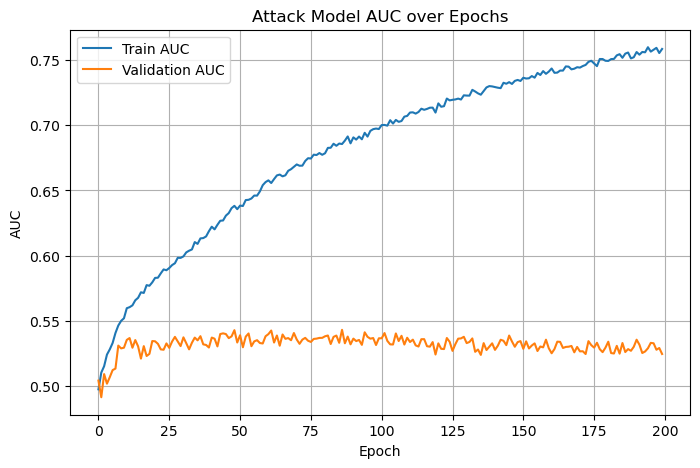

In [37]:
model_attack = AttackModel()
train_attack_model(model_attack, model_shadow, shadow_train_loader, shadow_test_loader, 200)

## Example of ID forgetting

In [39]:
# ---- Create all datasets and loaders ----
full_loader, train_loader, forget_loader  = create_train_set(train_dataset_full, num_forget=100)
test_loader, sample_loader, sample_indices = create_test_set(test_dataset_full, num_sample=500)

# ---- Optional: print summary ----
print(f"Training set (excluding forget): {len(train_loader.dataset)}")
print(f"Forget set: {len(forget_loader.dataset)}")
print(f"Test set (excluding sample): {len(test_loader.dataset)}")
print(f"Sample set: {len(sample_loader.dataset)}")

Training set (excluding forget): 59900
Forget set: 100
Test set (excluding sample): 9500
Sample set: 500


In [40]:
model_target = FullyConnectedNN()
model_target, unlearning_error = train_model_with_unlearning_error(model_target, full_loader, 0.01, 5)

Epoch 1/5, Loss: 0.7778
Epoch 2/5, Loss: 0.3067
Epoch 3/5, Loss: 0.2487
Epoch 4/5, Loss: 0.2104
Epoch 5/5, Loss: 0.1820

Unlearning Error (e): 24.4603


In [41]:
model_retrained = FullyConnectedNN()
train_model(model_retrained, train_loader, 0.01, 5)

Epoch 1/5, Loss: 0.7648
Epoch 2/5, Loss: 0.3084
Epoch 3/5, Loss: 0.2531
Epoch 4/5, Loss: 0.2157
Epoch 5/5, Loss: 0.1865


In [15]:
P = sample_P(model_target, sample_loader)
print(P)
print(sum(P))

tensor([0.0992, 0.1368, 0.0913, 0.0941, 0.1271, 0.0786, 0.0842, 0.1049, 0.1025,
        0.0814])
tensor(1.)


Omega set: 599
Computed omega: 759.9154
Iteration 1, Loss: 6.3224, Verification Error: 18.1515
Iteration 2, Loss: 6.3135, Verification Error: 18.1515
Iteration 3, Loss: 6.3047, Verification Error: 18.1515
Iteration 4, Loss: 6.2958, Verification Error: 18.1515
Iteration 5, Loss: 6.2869, Verification Error: 18.1515
Iteration 6, Loss: 6.3133, Verification Error: 18.1515
Iteration 7, Loss: 6.2536, Verification Error: 18.1515
Iteration 8, Loss: 6.2480, Verification Error: 18.1515
Iteration 9, Loss: 6.2480, Verification Error: 18.1515
Iteration 10, Loss: 6.2480, Verification Error: 18.1515
Iteration 11, Loss: 6.2480, Verification Error: 18.1515
Iteration 12, Loss: 6.2480, Verification Error: 18.1515
Iteration 13, Loss: 6.2480, Verification Error: 18.1515
Iteration 14, Loss: 6.2480, Verification Error: 18.1515
Iteration 15, Loss: 6.2480, Verification Error: 18.1515
Iteration 16, Loss: 6.2480, Verification Error: 18.1515
Iteration 17, Loss: 6.2480, Verification Error: 18.1515
Iteration 18, Los

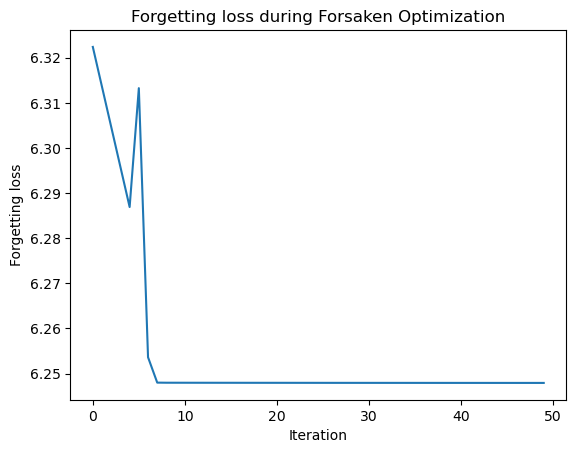

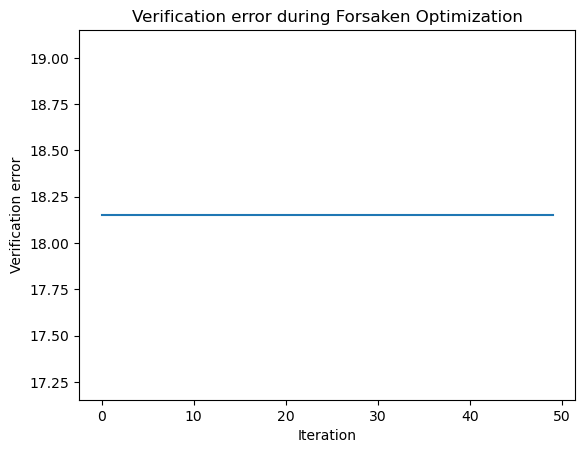

In [104]:
T = 50
lambda_ = 0.001
eta_mu = 0.01
xi = 0.01
p = 0.01

D_f, _ = next(iter(forget_loader))
omega_loader, omega_indices = create_omega_loader(train_loader.dataset, proportion=p)
print(f"Omega set: {len(omega_indices)}")
omega = compute_omega(model_target, omega_loader)
print(f"Computed omega: {omega:.4f}")

model_forsaken = forsaken(
    f_theta_0=model_target,
    T=T,
    lambda_=lambda_,
    omega=omega,
    P=P,
    D_f=D_f,
    eta_mu=eta_mu,
    xi=xi,
    optimizer = 'LBFGS',
    retrained_model = model_retrained
)


In [ ]:
accuracy = get_accuracy(model_forsaken, model_target, model_retrained, forget_loader, test_loader)

Accuracy sur D_f après Forsaken : 16.00%
Accuracy sur D_f sans Forsaken : 92.00%
Accuracy sur D_f avec réentraînement: 90.00%
Accuracy sur base de test après Forsaken : 11.82%
Accuracy sur base de test sans Forsaken : 95.13%
Accuracy sur base de test avec réentraînement : 94.95%


[16.0, 92.0, 90.0, 11.821052631578947, 95.12631578947368, 94.94736842105263]

In [ ]:
plot_hist(accuracy)

## Hyperparameter search for ID data

In [32]:
param_grid = {
        "T": [10, 50],
        "lambda_": [0.001, 0.01, 0.1],
        "eta_mu": [0.001, 0.01, 0.1],
        "xi": [0.001, 0.01, 0.1],
        "p": [0.001, 0.01]
    }

In [33]:
import itertools
import pandas as pd

def hyperparameter_search(param_grid, model_target, forget_loader, test_loader, model_retrained):
    results = []
    params_retrained = model_to_params(model_retrained)
    iteration = 1
    for config_values in itertools.product(*param_grid.values()):
        print(f"Search n°{iteration}")
        iteration += 1
        config = dict(zip(param_grid.keys(), config_values))
        try:
            # Compute omega with current p value
            omega_loader, _ = create_omega_loader(
                train_loader.dataset, 
                proportion=config["p"]
            )
            omega = compute_omega(model_target, omega_loader)
            
            # Get forget batch
            D_f, _ = next(iter(forget_loader))
            
            # Run Forsaken
            unlearned_model = forsaken(
                f_theta_0=model_target,
                T=config["T"],
                lambda_=config["lambda_"],
                omega=omega,
                P=P,
                D_f=D_f,
                eta_mu=config["eta_mu"],
                xi=config["xi"],
                optimizer='LBFGS',
                retrained_model=model_retrained,
                print_logs=False
            )
            
            # Compute metrics
            forget_acc = evaluate_model(unlearned_model, forget_loader)
            test_acc = evaluate_model(unlearned_model, test_loader)
            verification_err = verification_error(params_retrained, model_to_params(unlearned_model))
            
            # Store results
            results.append({
                **config,
                "forget_acc": forget_acc,
                "test_acc": test_acc,
                "verification_err": verification_err
            })
            
        except Exception as e:
            print(f"Failed config {config}: {str(e)}")
            continue

    return pd.DataFrame(results)

In [34]:
search_results = hyperparameter_search(
    model_target=model_target,
    forget_loader=forget_loader,
    test_loader=test_loader,
    model_retrained=model_retrained,
    param_grid=param_grid
)

Search n°1


c:\Users\alici\anaconda3\lib\site-packages\torch\nn\utils\stateless.py:214: UserWarning: This API is deprecated as of PyTorch 2.0 and will be removed in a future version of PyTorch. Please use torch.func.functional_call instead which is a drop-in replacement for this API.
  warnings.warn(


Search n°2
Search n°3
Search n°4
Search n°5
Search n°6
Search n°7
Search n°8
Search n°9
Search n°10
Search n°11
Search n°12
Search n°13
Search n°14
Search n°15
Search n°16
Search n°17
Search n°18
Search n°19
Search n°20
Search n°21
Search n°22
Search n°23
Search n°24
Search n°25
Search n°26
Search n°27
Search n°28
Search n°29
Search n°30
Search n°31
Search n°32
Search n°33
Search n°34
Search n°35
Search n°36
Search n°37
Search n°38
Search n°39
Search n°40
Search n°41
Search n°42
Search n°43
Search n°44
Search n°45
Search n°46
Search n°47
Search n°48
Search n°49
Search n°50
Search n°51
Search n°52
Search n°53
Search n°54
Search n°55
Search n°56
Search n°57
Search n°58
Search n°59
Search n°60
Search n°61
Search n°62
Search n°63
Search n°64
Search n°65
Search n°66
Search n°67
Search n°68
Search n°69
Search n°70
Search n°71
Search n°72
Search n°73
Search n°74
Search n°75
Search n°76
Search n°77
Search n°78
Search n°79
Search n°80
Search n°81
Search n°82
Search n°83
Search n°84
Search n°85


In [35]:
# Example analysis
print("\nTop 5 configurations by forget accuracy:")
print(search_results.sort_values('forget_acc').head(5))

print("\nConfigurations with test accuracy > 90%:")
print(search_results[search_results['test_acc'] > 90])

# Save full results
search_results.to_csv('unlearning_search_results.csv', index=False)


Top 5 configurations by forget accuracy:
     T  lambda_  eta_mu     xi      p  forget_acc  test_acc  \
51  10    0.100     0.1  0.010  0.010         2.0  7.031579   
13  10    0.001     0.1  0.001  0.010         3.0  9.705263   
86  50    0.010     0.1  0.010  0.001         5.0  9.105263   
30  10    0.010     0.1  0.001  0.001         7.0  9.684211   
49  10    0.100     0.1  0.001  0.010         7.0  6.105263   

      verification_err  
51   tensor(1427.5140)  
13    tensor(719.1661)  
86    tensor(628.6473)  
30   tensor(1827.8137)  
49  tensor(71935.7500)  

Configurations with test accuracy > 90%:
      T  lambda_  eta_mu     xi      p  forget_acc   test_acc verification_err
0    10    0.001   0.001  0.001  0.001        95.0  94.863158  tensor(18.0598)
1    10    0.001   0.001  0.001  0.010        95.0  94.863158  tensor(18.0598)
2    10    0.001   0.001  0.010  0.001        95.0  94.863158  tensor(18.0598)
3    10    0.001   0.001  0.010  0.010        95.0  94.863158  tensor(1

## Gaussian Poisoning

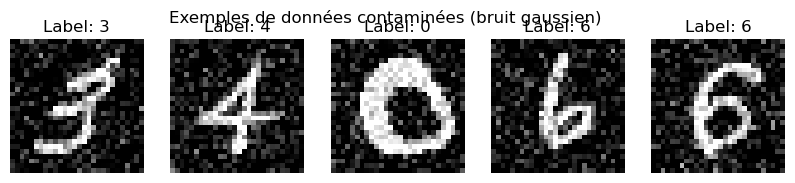

Taille du dataset total: 10000
Taille du dataset clean: 9000
Taille du dataset corrompu: 1000, 1000, 1000


In [42]:
epsilon = 0.05
loaders = create_train_set_gaussian(train_dataset_full, 0.1, epsilon, 10000, True)
print(f"Taille du dataset total: {len(loaders['full_loader'].dataset)}")
print(f"Taille du dataset clean: {len(loaders['clean_loader'].dataset)}")
print(f"Taille du dataset corrompu: {len(loaders['contaminated_loader'].dataset)}, "
      f"{len(loaders['base_contaminated_loader'].dataset)}, {len(loaders['noise_loader'].dataset)}")


In [100]:
model_noise = FullyConnectedNN()
#train_model(model_noise, train_loader=noisy_train_loader, lr=0.01, epochs=25)
model_noise, unlearning_error_noise = train_model_with_unlearning_error(model_noise, loaders["full_loader"], 0.01, 25)

Epoch 1/25, Loss: 2.2823
Epoch 2/25, Loss: 2.2031
Epoch 3/25, Loss: 2.0187
Epoch 4/25, Loss: 1.6542
Epoch 5/25, Loss: 1.2177
Epoch 6/25, Loss: 0.9109
Epoch 7/25, Loss: 0.7318
Epoch 8/25, Loss: 0.6218
Epoch 9/25, Loss: 0.5503
Epoch 10/25, Loss: 0.5001
Epoch 11/25, Loss: 0.4675
Epoch 12/25, Loss: 0.4350
Epoch 13/25, Loss: 0.4162
Epoch 14/25, Loss: 0.3957
Epoch 15/25, Loss: 0.3809
Epoch 16/25, Loss: 0.3680
Epoch 17/25, Loss: 0.3549
Epoch 18/25, Loss: 0.3463
Epoch 19/25, Loss: 0.3363
Epoch 20/25, Loss: 0.3298
Epoch 21/25, Loss: 0.3210
Epoch 22/25, Loss: 0.3163
Epoch 23/25, Loss: 0.3077
Epoch 24/25, Loss: 0.3002
Epoch 25/25, Loss: 0.2943

Unlearning Error (e): 15.3036


In [44]:
model_clean = FullyConnectedNN()
train_model(model_clean, loaders["clean_loader"], 0.01, 25)

Epoch 1/25, Loss: 2.2710
Epoch 2/25, Loss: 2.1793
Epoch 3/25, Loss: 1.9951
Epoch 4/25, Loss: 1.6758
Epoch 5/25, Loss: 1.2599
Epoch 6/25, Loss: 0.9375
Epoch 7/25, Loss: 0.7483
Epoch 8/25, Loss: 0.6339
Epoch 9/25, Loss: 0.5593
Epoch 10/25, Loss: 0.5067
Epoch 11/25, Loss: 0.4693
Epoch 12/25, Loss: 0.4385
Epoch 13/25, Loss: 0.4151
Epoch 14/25, Loss: 0.3966
Epoch 15/25, Loss: 0.3806
Epoch 16/25, Loss: 0.3658
Epoch 17/25, Loss: 0.3551
Epoch 18/25, Loss: 0.3444
Epoch 19/25, Loss: 0.3350
Epoch 20/25, Loss: 0.3275
Epoch 21/25, Loss: 0.3192
Epoch 22/25, Loss: 0.3124
Epoch 23/25, Loss: 0.3061
Epoch 24/25, Loss: 0.3000
Epoch 25/25, Loss: 0.2945


In [45]:
test_loader_gaussian, sample_loader_gaussian, sample_indices_gaussian = create_test_set(test_dataset_full, num_sample=500)

In [101]:
P = sample_P(model_noise, sample_loader_gaussian)
print(P)
print(sum(P))


tensor([0.1040, 0.1111, 0.0940, 0.0902, 0.1207, 0.0870, 0.0978, 0.1015, 0.1037,
        0.0900])
tensor(1.0000)


c:\Users\alici\anaconda3\lib\site-packages\torch\nn\utils\stateless.py:214: UserWarning: This API is deprecated as of PyTorch 2.0 and will be removed in a future version of PyTorch. Please use torch.func.functional_call instead which is a drop-in replacement for this API.
  warnings.warn(


Iteration 1, Loss: 0.1597, Verification Error: 18.3445
Fin de la procédure Forsaken.


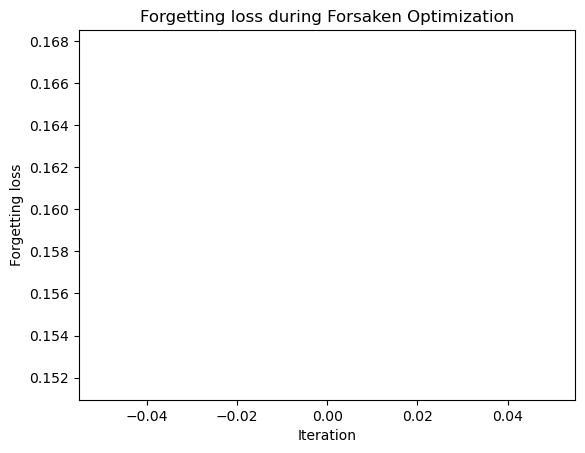

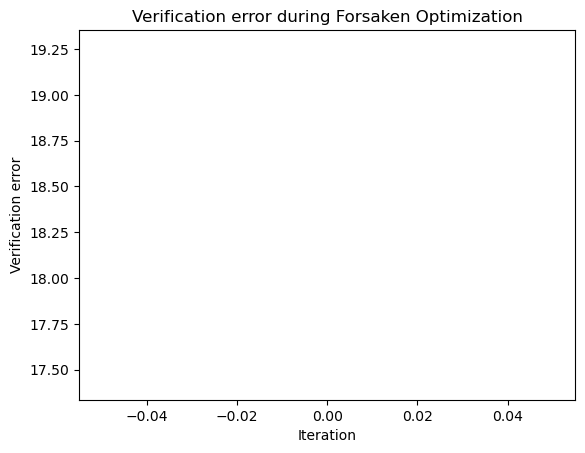

In [133]:
T = 1
lambda_ = 0.00
eta_mu = 0.1
xi = 0.01

D_f, _ = next(iter(loaders["contaminated_loader"]))
omega = 1.0

model_forsaken = forsaken(
    f_theta_0=model_noise,
    T=T,
    lambda_=lambda_,
    omega=omega,
    P=P,
    D_f=D_f,
    eta_mu=eta_mu,
    xi=xi,
    optimizer = 'LBFGS',
    retrained_model = model_clean
)


In [134]:
accuracies_gus = get_accuracy(model_forsaken, model_noise, model_clean, loaders["contaminated_loader"], test_loader_gaussian)


Accuracy sur D_f après Forsaken : 77.70%
Accuracy sur D_f sans Forsaken : 91.50%
Accuracy sur D_f avec réentraînement: 89.10%
Accuracy sur base de test après Forsaken : 84.34%
Accuracy sur base de test sans Forsaken : 89.84%
Accuracy sur base de test avec réentraînement : 88.21%


In [128]:
clean_gus = compute_gus_score(model_clean, loaders["base_contaminated_loader"], loaders["noise_loader"], epsilon)
noise_gus = compute_gus_score(model_noise, loaders["base_contaminated_loader"], loaders["noise_loader"], epsilon)
forsaken_gus = compute_gus_score(model_forsaken, loaders["base_contaminated_loader"], loaders["noise_loader"], epsilon)

print(f"Clean GUS: {clean_gus}")
print(f"Noise GUS: {noise_gus}")
print(f"Forsaken GUS: {forsaken_gus}")

Clean GUS: 0.03968507796525955
Noise GUS: -0.40464144945144653
Forsaken GUS: -0.027999816462397575


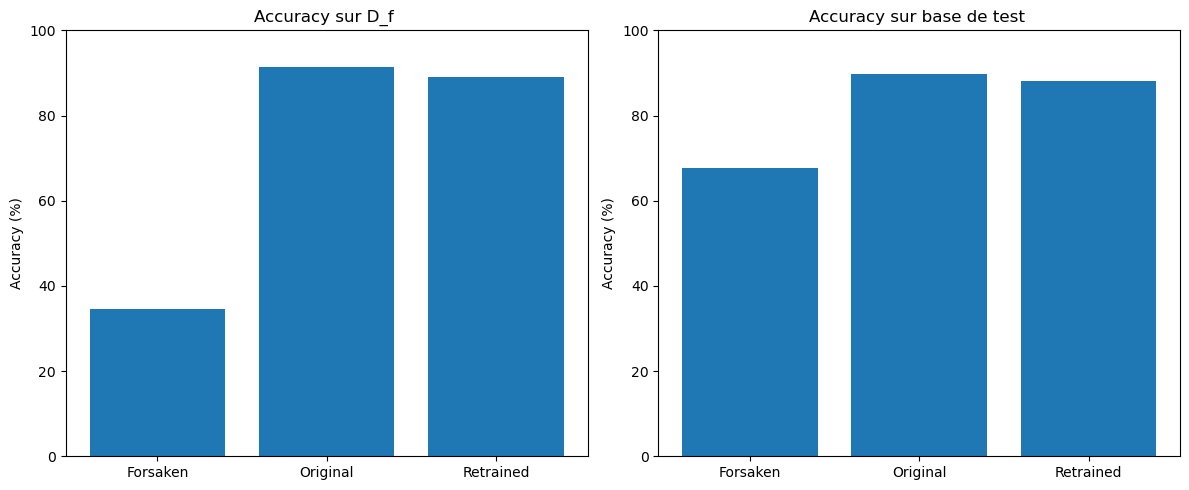

In [109]:
plot_hist(accuracies_gus)

In [161]:
import numpy as np
def sweep_xi_and_plot(
    xi_values,
    model_noise,
    model_clean,
    loaders,
    T=1,
    lambda_=0.0,
    eta_mu=0.1,
    omega=1.0,
    optimizer='LBFGS',
    epsilon=1e-4,
    P=None
):
    gus_scores = []
    test_accuracies = []
    forget_accuracies = []

    D_f, _ = next(iter(loaders["contaminated_loader"]))

    for xi in xi_values:
        print(f"\n--- Running forsaken with xi = {xi:.4f} ---")

        model_forsaken = forsaken(
            f_theta_0=model_noise,
            T=T,
            lambda_=lambda_,
            omega=omega,
            P=P,
            D_f=D_f,
            eta_mu=eta_mu,
            xi=xi,
            optimizer=optimizer,
            retrained_model=model_clean,
            print_logs=False
        )

        gus = abs(compute_gus_score(model_forsaken, loaders["base_contaminated_loader"], loaders["noise_loader"], epsilon))
        test_acc = evaluate_model(model_forsaken, test_loader_gaussian)
        forget_acc = evaluate_model(model_forsaken, loaders["contaminated_loader"])

        gus_scores.append(gus)
        test_accuracies.append(test_acc)
        forget_accuracies.append(forget_acc)

        print(f"Test accuracy     : {test_acc:.4f}")
        print(f"Forget accuracy   : {forget_acc:.4f}")
        print(f"Absolute GUS score: {gus:.4f}")

    # --- Find Best xi values ---
    best_test_idx = int(np.argmax(test_accuracies))
    best_forget_idx = int(np.argmax(forget_accuracies))
    best_gus_idx = int(np.argmin(gus_scores))

    print("\n=== Optimal xi values ===")
    print(f"xi maximizing test accuracy      : {xi_values[best_test_idx]:.4f} (Accuracy: {test_accuracies[best_test_idx]:.4f})")
    print(f"xi maximizing forget accuracy    : {xi_values[best_forget_idx]:.4f} (Accuracy: {forget_accuracies[best_forget_idx]:.4f})")
    print(f"xi minimizing absolute GUS score : {xi_values[best_gus_idx]:.4f} (GUS: {gus_scores[best_gus_idx]:.4f})")

    # --- Plotting ---
    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.plot(xi_values, gus_scores, marker='o', color='tab:blue')
    plt.xlabel("xi")
    plt.xscale("log")
    plt.ylabel("Absolute GUS")
    plt.title("Absolute GUS vs xi")
    plt.grid(True)

    plt.subplot(1, 3, 2)
    plt.plot(xi_values, test_accuracies, marker='o', color='tab:green')
    plt.xlabel("xi")
    plt.xscale("log")
    plt.ylabel("Test Accuracy")
    plt.title("Test Accuracy vs xi")
    plt.grid(True)

    plt.subplot(1, 3, 3)
    plt.plot(xi_values, forget_accuracies, marker='o', color='tab:red')
    plt.xlabel("xi")
    plt.xscale("log")
    plt.ylabel("Forget Accuracy")
    plt.title("Forget Accuracy vs xi")
    plt.grid(True)

    plt.tight_layout()
    plt.show()



--- Running forsaken with xi = 0.0010 ---


c:\Users\alici\anaconda3\lib\site-packages\torch\nn\utils\stateless.py:214: UserWarning: This API is deprecated as of PyTorch 2.0 and will be removed in a future version of PyTorch. Please use torch.func.functional_call instead which is a drop-in replacement for this API.
  warnings.warn(


Test accuracy     : 89.8421
Forget accuracy   : 91.5000
Absolute GUS score: 0.4046

--- Running forsaken with xi = 0.0020 ---
Test accuracy     : 89.8421
Forget accuracy   : 91.5000
Absolute GUS score: 0.4046

--- Running forsaken with xi = 0.0030 ---
Test accuracy     : 89.8421
Forget accuracy   : 91.5000
Absolute GUS score: 0.4046

--- Running forsaken with xi = 0.0040 ---
Test accuracy     : 89.8421
Forget accuracy   : 91.5000
Absolute GUS score: 0.4048

--- Running forsaken with xi = 0.0050 ---
Test accuracy     : 85.0105
Forget accuracy   : 78.9000
Absolute GUS score: 0.0732

--- Running forsaken with xi = 0.0060 ---
Test accuracy     : 84.9789
Forget accuracy   : 78.9000
Absolute GUS score: 0.0725

--- Running forsaken with xi = 0.0070 ---
Test accuracy     : 80.2947
Forget accuracy   : 73.9000
Absolute GUS score: 0.0065

--- Running forsaken with xi = 0.0080 ---
Test accuracy     : 83.4737
Forget accuracy   : 76.8000
Absolute GUS score: 0.0067

--- Running forsaken with xi = 0.0

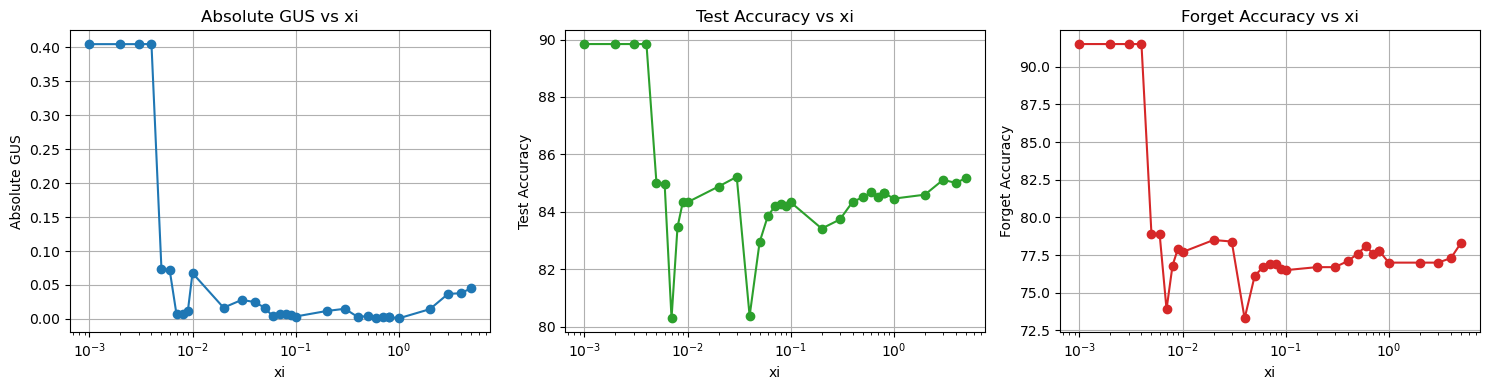

In [162]:
xi_range = [0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.009,
 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 
 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8,
 1, 2, 3, 4, 5]

sweep_xi_and_plot(
    xi_values=xi_range,
    model_noise=model_noise,
    model_clean=model_clean,
    loaders=loaders,
    P=P,
    epsilon=epsilon, 
    T = 1,
    eta_mu = 0.1
)




--- Running forsaken with xi = 0.0010 ---
Test accuracy     : 89.8421
Forget accuracy   : 91.5000
Absolute GUS score: 0.4046

--- Running forsaken with xi = 0.0020 ---
Test accuracy     : 89.8421
Forget accuracy   : 91.5000
Absolute GUS score: 0.4046

--- Running forsaken with xi = 0.0030 ---
Test accuracy     : 89.8421
Forget accuracy   : 91.5000
Absolute GUS score: 0.4046

--- Running forsaken with xi = 0.0040 ---
Test accuracy     : 89.8421
Forget accuracy   : 91.5000
Absolute GUS score: 0.4046

--- Running forsaken with xi = 0.0050 ---
Test accuracy     : 89.8421
Forget accuracy   : 91.5000
Absolute GUS score: 0.4046

--- Running forsaken with xi = 0.0060 ---
Test accuracy     : 89.8421
Forget accuracy   : 91.5000
Absolute GUS score: 0.4047

--- Running forsaken with xi = 0.0070 ---
Test accuracy     : 89.8421
Forget accuracy   : 91.5000
Absolute GUS score: 0.4048

--- Running forsaken with xi = 0.0080 ---
Test accuracy     : 89.8421
Forget accuracy   : 91.5000
Absolute GUS score:

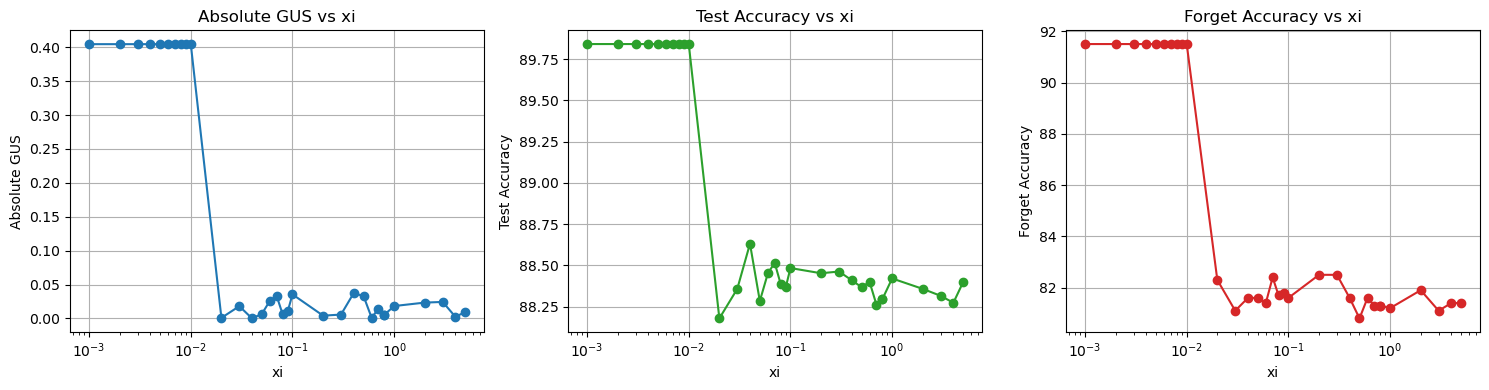

In [163]:
sweep_xi_and_plot(
    xi_values=xi_range,
    model_noise=model_noise,
    model_clean=model_clean,
    loaders=loaders,
    P=P,
    epsilon=epsilon, 
    T = 5,
    eta_mu = 0.01
)

In [ ]:
# Hyperparamètres fixes
lambda_ = 0.00
eta_mu = 0.01
xi = 0.04

# Extraction d’un batch pour D_f
D_f, _ = next(iter(loaders["contaminated_loader"]))

omega = 1.0  # forçage ici


# Liste des T à tester
T_values = list(range(1, 11))

# Stockage des accuracies
accuracies_forget = []
accuracies_test = []
gus_scores = []

# Boucle sur T
for T in T_values:
    print(f"\n==== FORSAKEN avec T = {T} ====")

    model_forsaken = forsaken(
        f_theta_0=model_noise,
        T=T,
        lambda_=lambda_,
        omega=omega,
        P=P,
        D_f=D_f,
        eta_mu=eta_mu,
        xi=xi,
        optimizer = 'LBFGS',
        retrained_model = model_clean,
        print_logs= False
)

    acc_forget = evaluate_model(model_forsaken, loaders["contaminated_loader"])
    acc_test = evaluate_model(model_forsaken, loaders["clean_loader"])
    gus_score = compute_gus_score(model_forsaken, loaders["base_contaminated_loader"], loaders["noise_loader"], epsilon)
    abs_gus = abs(gus_score)
    print(f"→ Accuracy D_f : {acc_forget:.2f}%, Accuracy test : {acc_test:.2f}%, GUS : {gus_score:.4f}")

    accuracies_forget.append(acc_forget)
    accuracies_test.append(acc_test)
    gus_scores.append(gus_score)


==== FORSAKEN avec T = 1 ====
→ Accuracy D_f : 90.10%, Accuracy test : 90.90%, GUS : -0.2888

==== FORSAKEN avec T = 2 ====
→ Accuracy D_f : 89.00%, Accuracy test : 90.00%, GUS : -0.2162

==== FORSAKEN avec T = 3 ====
→ Accuracy D_f : 87.60%, Accuracy test : 89.48%, GUS : -0.1355

==== FORSAKEN avec T = 4 ====
→ Accuracy D_f : 85.50%, Accuracy test : 88.36%, GUS : -0.0703

==== FORSAKEN avec T = 5 ====
→ Accuracy D_f : 81.60%, Accuracy test : 86.62%, GUS : 0.0000

==== FORSAKEN avec T = 6 ====
→ Accuracy D_f : 77.20%, Accuracy test : 85.10%, GUS : 0.0657

==== FORSAKEN avec T = 7 ====
→ Accuracy D_f : 73.80%, Accuracy test : 83.59%, GUS : 0.1394

==== FORSAKEN avec T = 8 ====
→ Accuracy D_f : 69.50%, Accuracy test : 82.52%, GUS : 0.1873

==== FORSAKEN avec T = 9 ====
→ Accuracy D_f : 64.90%, Accuracy test : 81.08%, GUS : 0.2244

==== FORSAKEN avec T = 10 ====
→ Accuracy D_f : 58.50%, Accuracy test : 79.38%, GUS : 0.2497


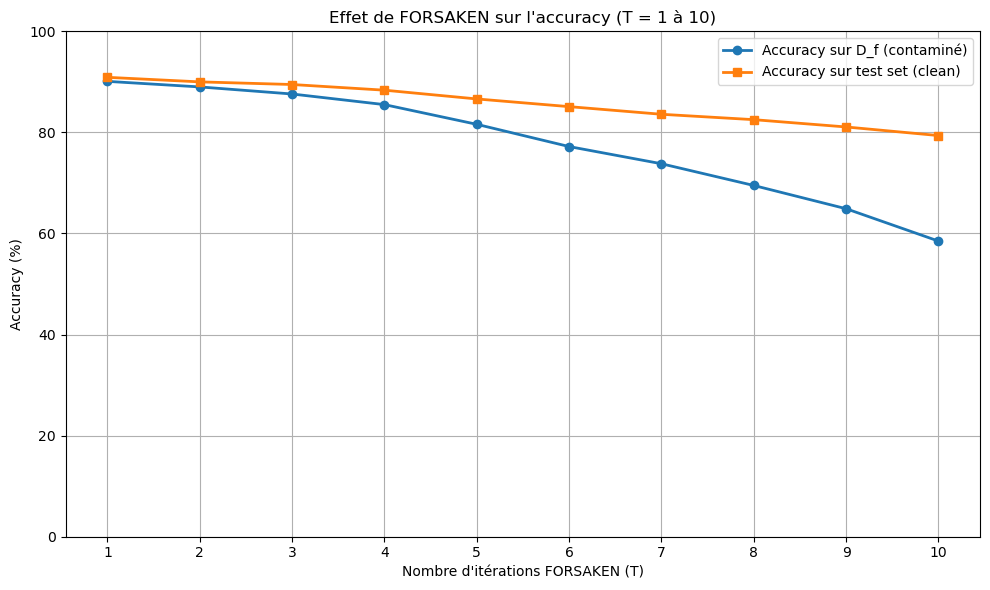

In [165]:
plot_forsaken_vs_accuracy(T_values, accuracies_forget, accuracies_test)

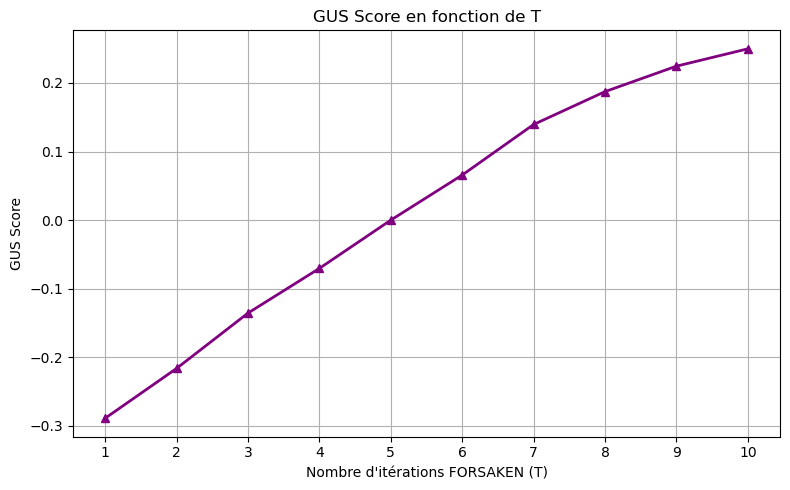

In [166]:
plot_gus_vs_T(T_values, gus_scores)

## Label Poisoning 

In [37]:
# ---------------------------
# 1. Chargement et transformation
# ---------------------------
transform = transforms.ToTensor()

# Chargement du dataset d'entraînement MNIST
mnist_train = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Chargement du dataset de test MNIST (clean)
mnist_test = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# ---------------------------
# 2. Application de la corruption sur l'ensemble d'entraînement uniquement
# ---------------------------
corrupted_train_images = []
corrupted_train_labels = []
corrupted_train_flags = []  # True si l'exemple est corrompu

for img, label in mnist_train:
    # Pour chaque image de label 1, on change le label en 7 avec 50 % de chance.
    if label == 1 and random.random() < 0.6:
        new_label = 7
        corrupted_train_flags.append(True)
    else:
        new_label = label
        corrupted_train_flags.append(False)
    corrupted_train_images.append(img)
    corrupted_train_labels.append(new_label)

# Création d'un TensorDataset pour l'ensemble d'entraînement corrompu
data_tensor_train = torch.stack(corrupted_train_images)        # (N, 1, 28, 28)
labels_tensor_train = torch.tensor(corrupted_train_labels)       # (N,)
flags_tensor_train = torch.tensor(corrupted_train_flags)         # (N,)

corrupted_train_dataset = TensorDataset(data_tensor_train, labels_tensor_train, flags_tensor_train)

# Pour le test, on utilise directement le dataset clean
clean_test_dataset = mnist_test

# ---------------------------
# 3. Création des DataLoaders
# ---------------------------
corrupted_train_loader = DataLoader(corrupted_train_dataset, batch_size=64, shuffle=True)
clean_test_loader = DataLoader(clean_test_dataset, batch_size=64, shuffle=False)

# ---------------------------
# 4. Vérification (optionnelle)
# ---------------------------
def count_corrupted(dataset):
    count = 0
    for sample in dataset:
        # Chaque échantillon est (image, label, flag)
        if sample[2]:
            count += 1
    return count

print("Nombre total d'exemples dans l'ensemble d'entraînement :", len(corrupted_train_dataset))
print("Nombre d'exemples corrompus dans l'ensemble d'entraînement :", count_corrupted(corrupted_train_dataset))
print("Nombre total d'exemples dans l'ensemble de test :", len(clean_test_dataset))


Nombre total d'exemples dans l'ensemble d'entraînement : 60000
Nombre d'exemples corrompus dans l'ensemble d'entraînement : 4054
Nombre total d'exemples dans l'ensemble de test : 10000


In [38]:
# =============================================================================
# 4. Entraînement du modèle sur le dataset corrompu
# =============================================================================
model_corrupted = FullyConnectedNN()
train_model_corrupted(model_corrupted, corrupted_train_loader, lr=0.01, epochs=5)

Epoch 1/5, Loss: 1.7180
Epoch 2/5, Loss: 0.6491
Epoch 3/5, Loss: 0.4775
Epoch 4/5, Loss: 0.4195
Epoch 5/5, Loss: 0.3852


C:\Users\mathi\AppData\Local\Temp\ipykernel_19408\1228886486.py:21: FutureWarning: `torch.nn.utils.stateless.functional_call` is deprecated as of PyTorch 2.0 and will be removed in a future version of PyTorch. Please use `torch.func.functional_call` instead which is a drop-in replacement.
  upsilon = functional_call(model_t, new_params, D_f)


Iteration 1, Loss: 3.4571, Verification Error: 0.0008
Iteration 2, Loss: 3.3793, Verification Error: 0.0923
Iteration 3, Loss: 3.3137, Verification Error: 0.1172
Iteration 4, Loss: 3.2333, Verification Error: 0.1458
Iteration 5, Loss: 3.1656, Verification Error: 0.1677
Iteration 6, Loss: 3.0981, Verification Error: 0.1893
Iteration 7, Loss: 3.0332, Verification Error: 0.2058
Iteration 8, Loss: 2.9913, Verification Error: 0.2123
Iteration 9, Loss: 2.9625, Verification Error: 0.2214
Iteration 10, Loss: 2.9394, Verification Error: 0.2316
Iteration 11, Loss: 2.9198, Verification Error: 0.2381
Iteration 12, Loss: 2.9055, Verification Error: 0.2384
Iteration 13, Loss: 2.8905, Verification Error: 0.2457
Iteration 14, Loss: 2.8744, Verification Error: 0.2558
Iteration 15, Loss: 2.8580, Verification Error: 0.2556
Iteration 16, Loss: 2.8428, Verification Error: 0.2612
Iteration 17, Loss: 2.8245, Verification Error: 0.2727
Iteration 18, Loss: 2.8109, Verification Error: 0.2760
Iteration 19, Loss:

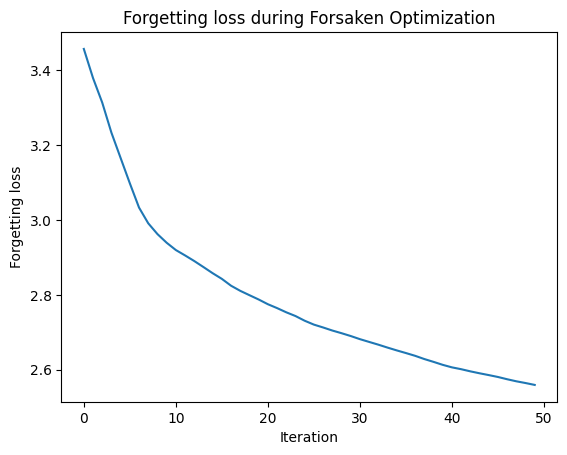

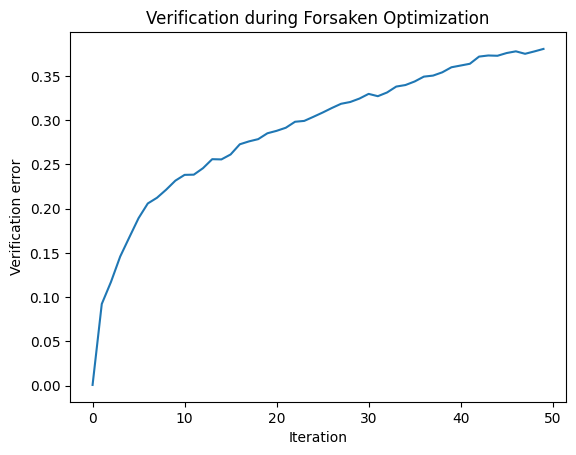

In [39]:

# =============================================================================
# 5. Création du forget set ciblé sur les points corrompus
# =============================================================================
forget_loader_corrupted, D_f_corrupted = forget_set_corrupted(corrupted_train_dataset)
images_forget, labels_forget, _ = next(iter(forget_loader_corrupted))
# Création d'une distribution uniforme pour P (pour la KL-divergence)
P = torch.full((images_forget.size(0), 10), 1/10)

# =============================================================================
# 6. Application de la procédure Forsaken
# =============================================================================
T = 50
lambda_ = 0.1
omega = 1.0
eta_mu = 0.2
xi = 1.0

model_corrupted_forsaken = forsaken_corrupted(
    f_theta_0=model_corrupted,
    T=T,
    lambda_=lambda_,
    omega=omega,
    P=P,
    D_f=images_forget,  # Batch d'images du forget set
    eta_mu=eta_mu,
    xi=xi,
    optimizer='LBFGS'
)


In [40]:
# 1. Récupérer les tensors originaux
images = data_tensor_train
labels = labels_tensor_train
flags = flags_tensor_train  # True si corrompu

# 2. Créer un masque pour garder les exemples non corrompus
retain_mask = ~flags  # Inverse des corrompus → True pour ce qu'on veut garder

# 3. Appliquer le masque pour extraire les exemples à retenir
retain_images = images[retain_mask]
retain_labels = labels[retain_mask]
retain_flags = flags[retain_mask]

# 4. Créer le dataset et DataLoader
retain_dataset = TensorDataset(retain_images, retain_labels, retain_flags)
retain_loader = DataLoader(retain_dataset, batch_size=64, shuffle=True)


In [41]:
model_retrained = FullyConnectedNN()
train_model_corrupted(model_retrained, retain_loader, lr=0.01, epochs=5)


Epoch 1/5, Loss: 1.7028
Epoch 2/5, Loss: 0.5964
Epoch 3/5, Loss: 0.4098
Epoch 4/5, Loss: 0.3539
Epoch 5/5, Loss: 0.3214


In [42]:
# =============================================================================
# 7. Évaluation centralisée via get_accuracy
# =============================================================================
accuracies_corrupted = get_accuracy_corrupted(
    model_forsaken=model_corrupted_forsaken,
    model_target=model_corrupted,
    model_retrained=model_retrained,
    forget_loader=forget_loader_corrupted,
    test_loader=clean_test_loader
)


Accuracy sur D_f après Forsaken : 25.00%
Accuracy sur D_f sans Forsaken : 79.00%
Accuracy sur D_f avec réentraînement: 0.00%
Accuracy sur base de test après Forsaken : 82.44%
Accuracy sur base de test sans Forsaken : 83.02%
Accuracy sur base de test avec réentraînement : 91.51%


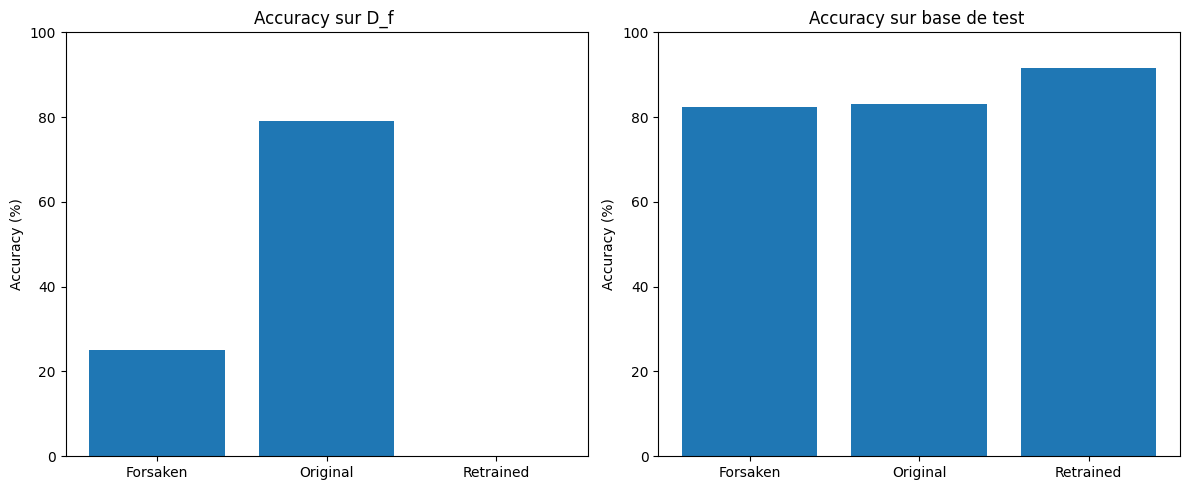

In [43]:
plot_hist(accuracies_corrupted)


==== FORSAKEN avec T = 1 ====


C:\Users\mathi\AppData\Local\Temp\ipykernel_19408\1228886486.py:21: FutureWarning: `torch.nn.utils.stateless.functional_call` is deprecated as of PyTorch 2.0 and will be removed in a future version of PyTorch. Please use `torch.func.functional_call` instead which is a drop-in replacement.
  upsilon = functional_call(model_t, new_params, D_f)


Iteration 1, Loss: 3.4571, Verification Error: 0.0008
Fin de la procédure Forsaken.


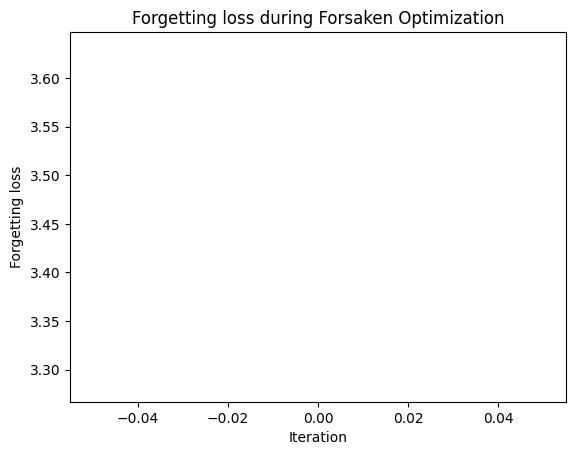

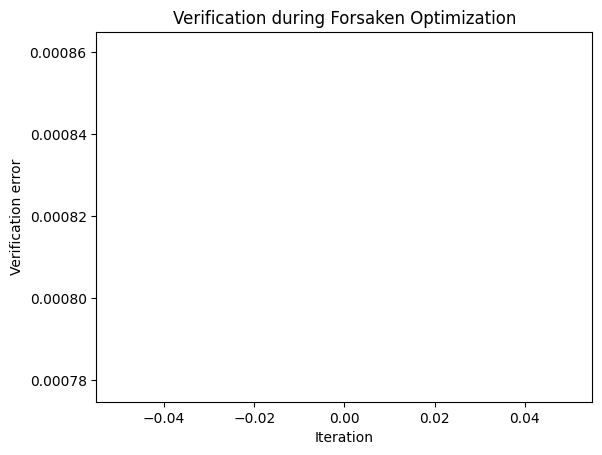

→ Accuracy D_f : 77.00%, Accuracy test : 83.03%

==== FORSAKEN avec T = 2 ====
Iteration 1, Loss: 3.4571, Verification Error: 0.0008
Iteration 2, Loss: 3.3793, Verification Error: 0.0923
Fin de la procédure Forsaken.


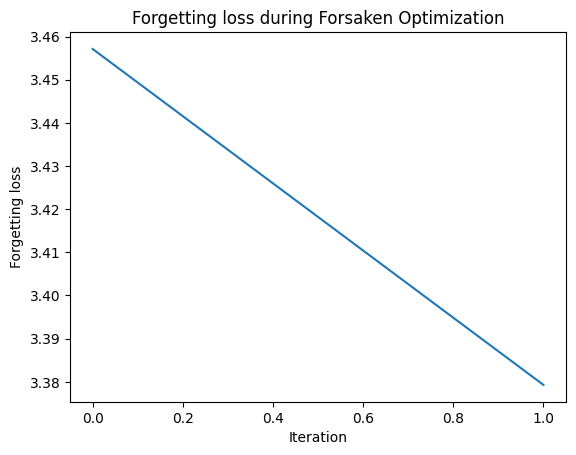

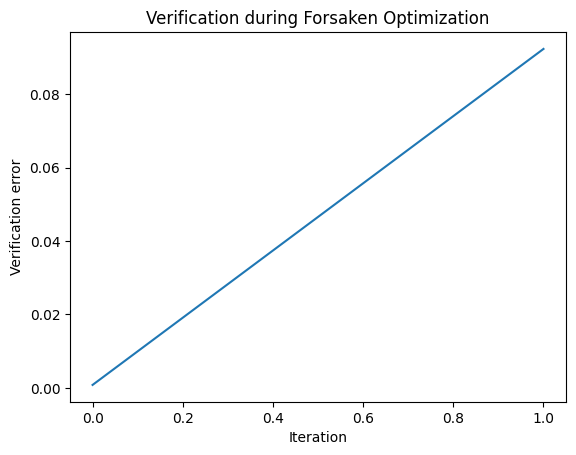

→ Accuracy D_f : 31.00%, Accuracy test : 86.50%

==== FORSAKEN avec T = 3 ====
Iteration 1, Loss: 3.4571, Verification Error: 0.0008
Iteration 2, Loss: 3.3793, Verification Error: 0.0923
Iteration 3, Loss: 3.3137, Verification Error: 0.1172
Fin de la procédure Forsaken.


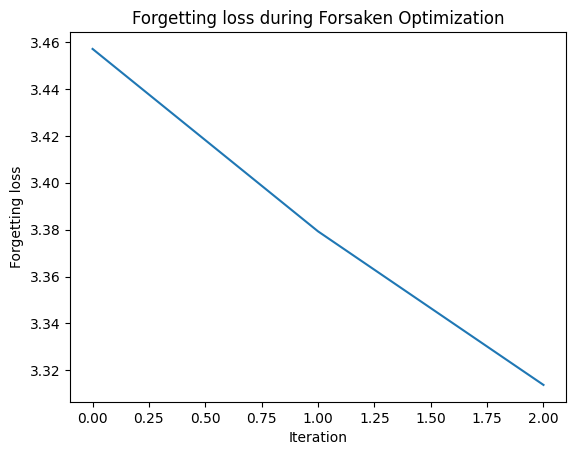

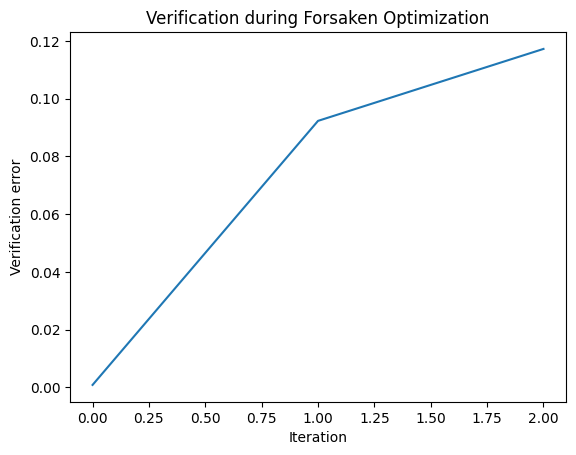

→ Accuracy D_f : 25.00%, Accuracy test : 87.04%

==== FORSAKEN avec T = 4 ====
Iteration 1, Loss: 3.4571, Verification Error: 0.0008
Iteration 2, Loss: 3.3793, Verification Error: 0.0923
Iteration 3, Loss: 3.3137, Verification Error: 0.1172
Iteration 4, Loss: 3.2333, Verification Error: 0.1458
Fin de la procédure Forsaken.


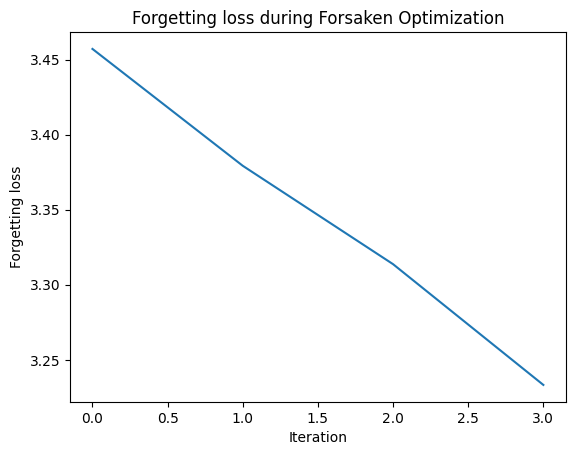

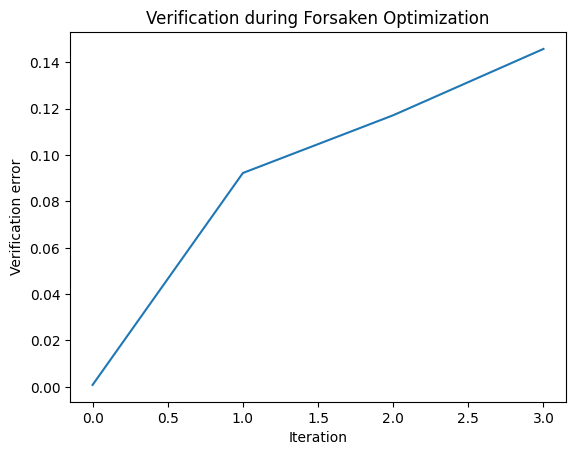

→ Accuracy D_f : 23.00%, Accuracy test : 87.18%

==== FORSAKEN avec T = 5 ====
Iteration 1, Loss: 3.4571, Verification Error: 0.0008
Iteration 2, Loss: 3.3793, Verification Error: 0.0923
Iteration 3, Loss: 3.3137, Verification Error: 0.1172
Iteration 4, Loss: 3.2333, Verification Error: 0.1458
Iteration 5, Loss: 3.1656, Verification Error: 0.1677
Fin de la procédure Forsaken.


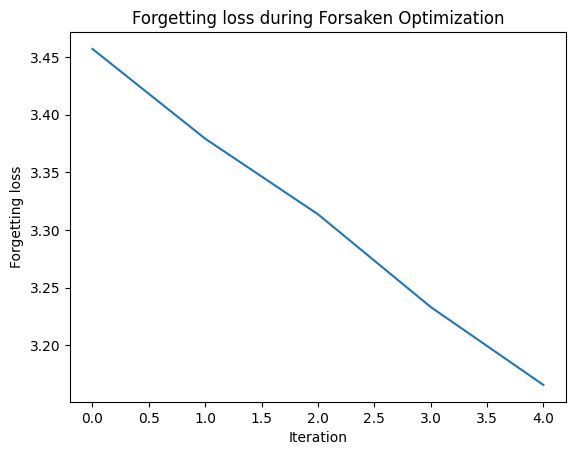

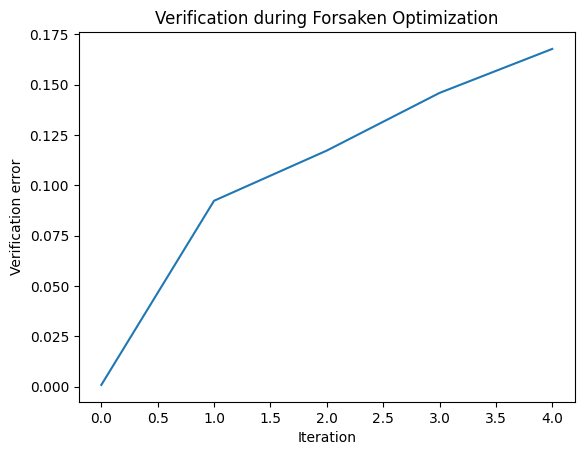

→ Accuracy D_f : 18.00%, Accuracy test : 86.98%

==== FORSAKEN avec T = 6 ====
Iteration 1, Loss: 3.4571, Verification Error: 0.0008
Iteration 2, Loss: 3.3793, Verification Error: 0.0923
Iteration 3, Loss: 3.3137, Verification Error: 0.1172
Iteration 4, Loss: 3.2333, Verification Error: 0.1458
Iteration 5, Loss: 3.1656, Verification Error: 0.1677
Iteration 6, Loss: 3.0981, Verification Error: 0.1893
Fin de la procédure Forsaken.


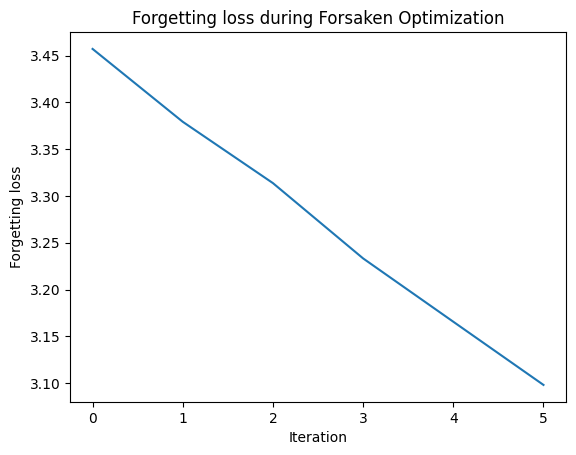

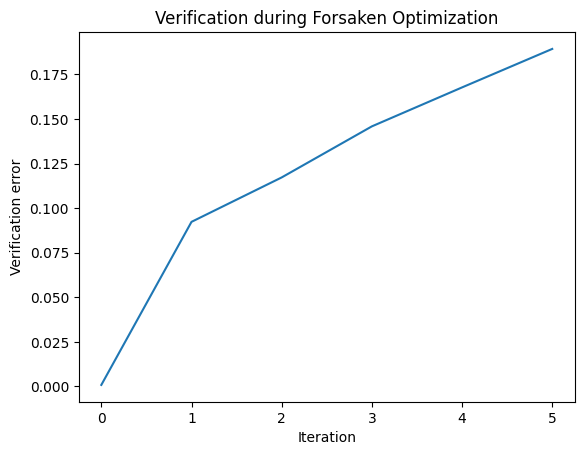

→ Accuracy D_f : 17.00%, Accuracy test : 86.81%

==== FORSAKEN avec T = 7 ====
Iteration 1, Loss: 3.4571, Verification Error: 0.0008
Iteration 2, Loss: 3.3793, Verification Error: 0.0923
Iteration 3, Loss: 3.3137, Verification Error: 0.1172
Iteration 4, Loss: 3.2333, Verification Error: 0.1458
Iteration 5, Loss: 3.1656, Verification Error: 0.1677
Iteration 6, Loss: 3.0981, Verification Error: 0.1893
Iteration 7, Loss: 3.0332, Verification Error: 0.2058
Fin de la procédure Forsaken.


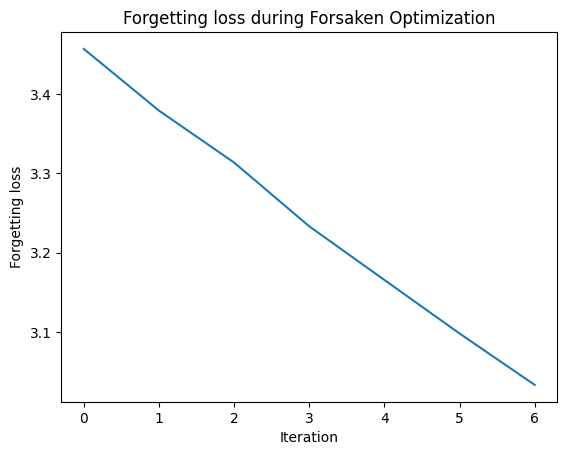

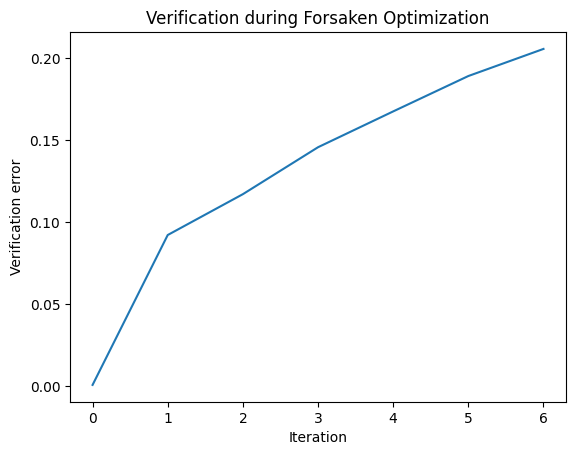

→ Accuracy D_f : 15.00%, Accuracy test : 86.63%

==== FORSAKEN avec T = 8 ====
Iteration 1, Loss: 3.4571, Verification Error: 0.0008
Iteration 2, Loss: 3.3793, Verification Error: 0.0923
Iteration 3, Loss: 3.3137, Verification Error: 0.1172
Iteration 4, Loss: 3.2333, Verification Error: 0.1458
Iteration 5, Loss: 3.1656, Verification Error: 0.1677
Iteration 6, Loss: 3.0981, Verification Error: 0.1893
Iteration 7, Loss: 3.0332, Verification Error: 0.2058
Iteration 8, Loss: 2.9913, Verification Error: 0.2123
Fin de la procédure Forsaken.


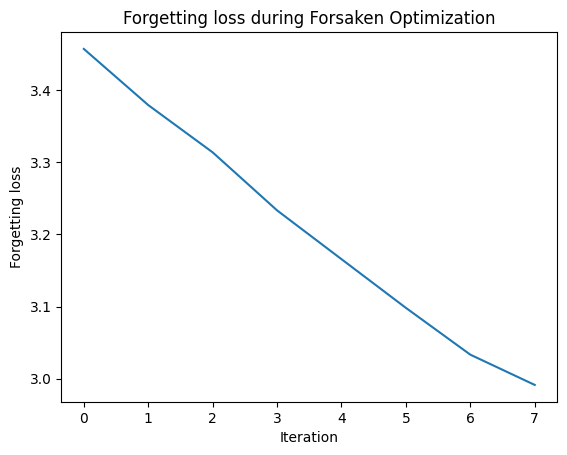

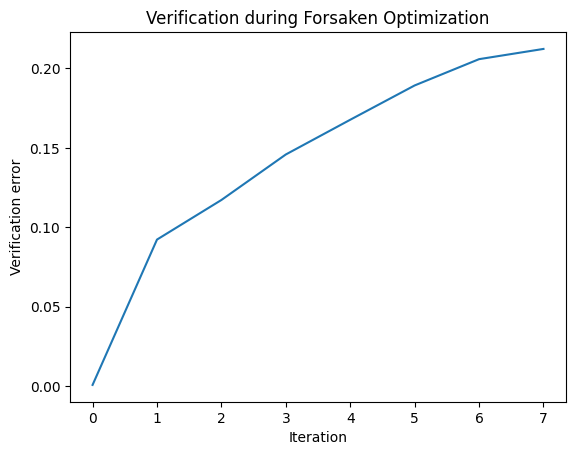

→ Accuracy D_f : 15.00%, Accuracy test : 86.55%

==== FORSAKEN avec T = 9 ====
Iteration 1, Loss: 3.4571, Verification Error: 0.0008
Iteration 2, Loss: 3.3793, Verification Error: 0.0923
Iteration 3, Loss: 3.3137, Verification Error: 0.1172
Iteration 4, Loss: 3.2333, Verification Error: 0.1458
Iteration 5, Loss: 3.1656, Verification Error: 0.1677
Iteration 6, Loss: 3.0981, Verification Error: 0.1893
Iteration 7, Loss: 3.0332, Verification Error: 0.2058
Iteration 8, Loss: 2.9913, Verification Error: 0.2123
Iteration 9, Loss: 2.9625, Verification Error: 0.2214
Fin de la procédure Forsaken.


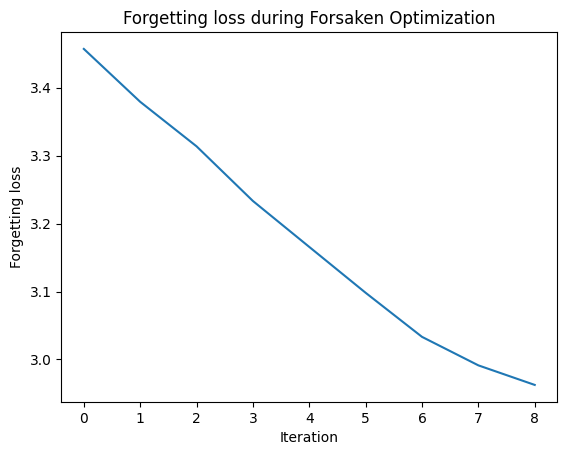

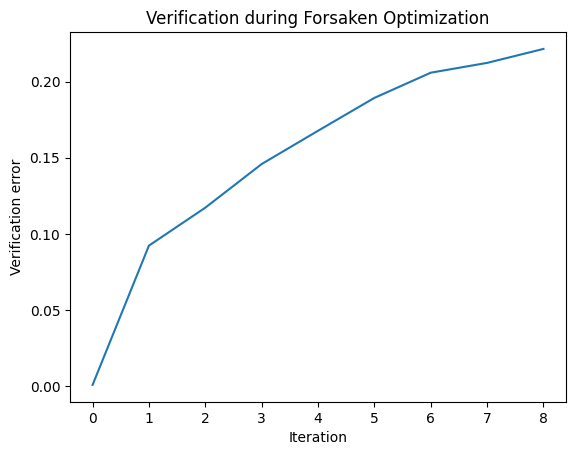

→ Accuracy D_f : 16.00%, Accuracy test : 86.33%

==== FORSAKEN avec T = 10 ====
Iteration 1, Loss: 3.4571, Verification Error: 0.0008
Iteration 2, Loss: 3.3793, Verification Error: 0.0923
Iteration 3, Loss: 3.3137, Verification Error: 0.1172
Iteration 4, Loss: 3.2333, Verification Error: 0.1458
Iteration 5, Loss: 3.1656, Verification Error: 0.1677
Iteration 6, Loss: 3.0981, Verification Error: 0.1893
Iteration 7, Loss: 3.0332, Verification Error: 0.2058
Iteration 8, Loss: 2.9913, Verification Error: 0.2123
Iteration 9, Loss: 2.9625, Verification Error: 0.2214
Iteration 10, Loss: 2.9394, Verification Error: 0.2316
Fin de la procédure Forsaken.


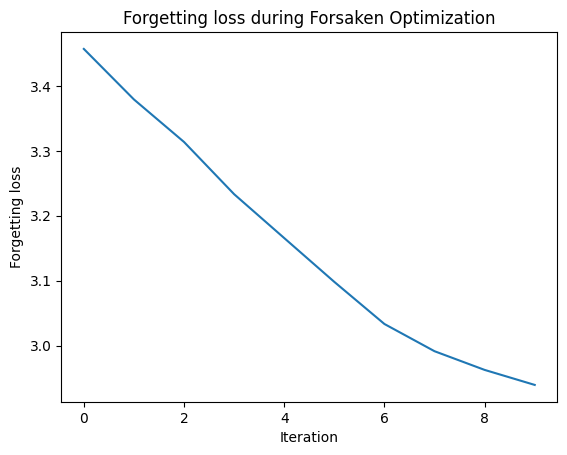

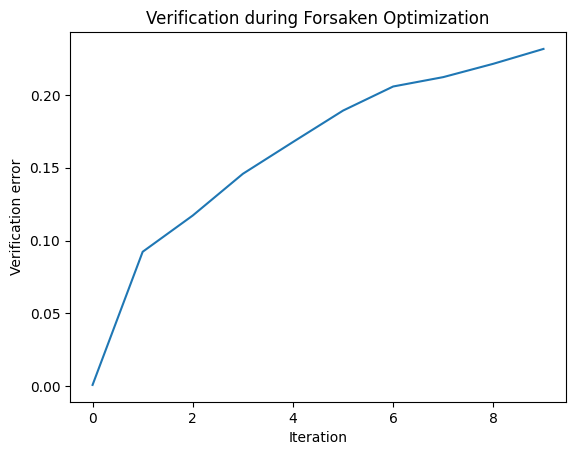

→ Accuracy D_f : 15.00%, Accuracy test : 86.24%

==== FORSAKEN avec T = 20 ====
Iteration 1, Loss: 3.4571, Verification Error: 0.0008
Iteration 2, Loss: 3.3793, Verification Error: 0.0923
Iteration 3, Loss: 3.3137, Verification Error: 0.1172
Iteration 4, Loss: 3.2333, Verification Error: 0.1458
Iteration 5, Loss: 3.1656, Verification Error: 0.1677
Iteration 6, Loss: 3.0981, Verification Error: 0.1893
Iteration 7, Loss: 3.0332, Verification Error: 0.2058
Iteration 8, Loss: 2.9913, Verification Error: 0.2123
Iteration 9, Loss: 2.9625, Verification Error: 0.2214
Iteration 10, Loss: 2.9394, Verification Error: 0.2316
Iteration 11, Loss: 2.9198, Verification Error: 0.2381
Iteration 12, Loss: 2.9055, Verification Error: 0.2384
Iteration 13, Loss: 2.8905, Verification Error: 0.2457
Iteration 14, Loss: 2.8744, Verification Error: 0.2558
Iteration 15, Loss: 2.8580, Verification Error: 0.2556
Iteration 16, Loss: 2.8428, Verification Error: 0.2612
Iteration 17, Loss: 2.8245, Verification Error: 0

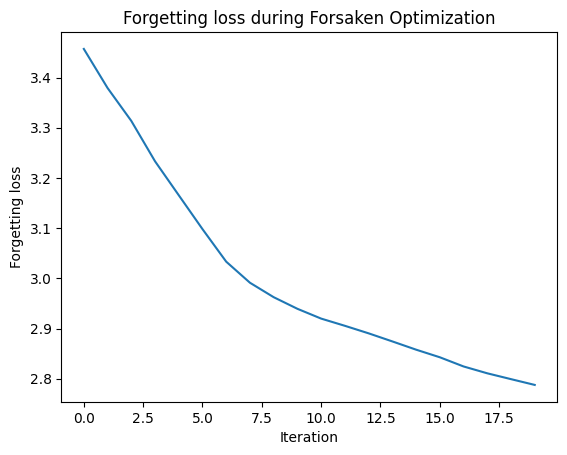

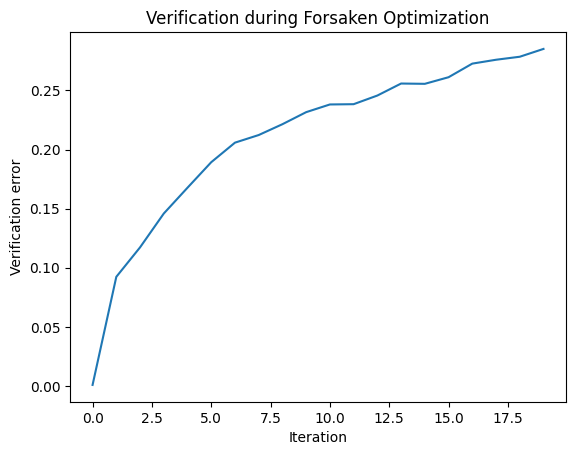

→ Accuracy D_f : 16.00%, Accuracy test : 85.15%

==== FORSAKEN avec T = 30 ====
Iteration 1, Loss: 3.4571, Verification Error: 0.0008
Iteration 2, Loss: 3.3793, Verification Error: 0.0923
Iteration 3, Loss: 3.3137, Verification Error: 0.1172
Iteration 4, Loss: 3.2333, Verification Error: 0.1458
Iteration 5, Loss: 3.1656, Verification Error: 0.1677
Iteration 6, Loss: 3.0981, Verification Error: 0.1893
Iteration 7, Loss: 3.0332, Verification Error: 0.2058
Iteration 8, Loss: 2.9913, Verification Error: 0.2123
Iteration 9, Loss: 2.9625, Verification Error: 0.2214
Iteration 10, Loss: 2.9394, Verification Error: 0.2316
Iteration 11, Loss: 2.9198, Verification Error: 0.2381
Iteration 12, Loss: 2.9055, Verification Error: 0.2384
Iteration 13, Loss: 2.8905, Verification Error: 0.2457
Iteration 14, Loss: 2.8744, Verification Error: 0.2558
Iteration 15, Loss: 2.8580, Verification Error: 0.2556
Iteration 16, Loss: 2.8428, Verification Error: 0.2612
Iteration 17, Loss: 2.8245, Verification Error: 0

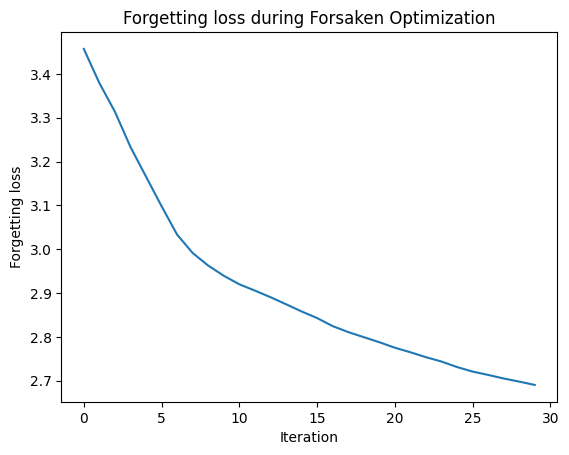

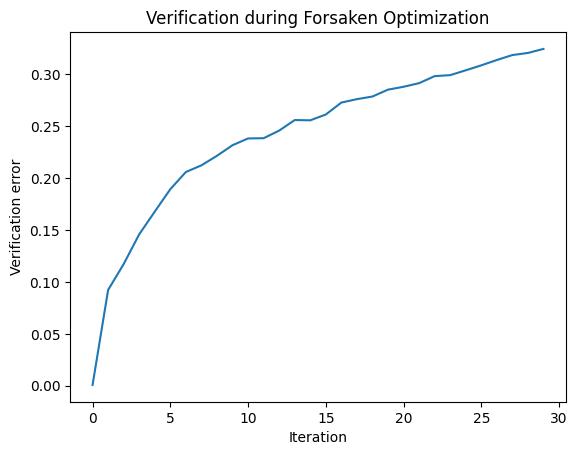

→ Accuracy D_f : 17.00%, Accuracy test : 84.17%

==== FORSAKEN avec T = 40 ====
Iteration 1, Loss: 3.4571, Verification Error: 0.0008
Iteration 2, Loss: 3.3793, Verification Error: 0.0923
Iteration 3, Loss: 3.3137, Verification Error: 0.1172
Iteration 4, Loss: 3.2333, Verification Error: 0.1458
Iteration 5, Loss: 3.1656, Verification Error: 0.1677
Iteration 6, Loss: 3.0981, Verification Error: 0.1893
Iteration 7, Loss: 3.0332, Verification Error: 0.2058
Iteration 8, Loss: 2.9913, Verification Error: 0.2123
Iteration 9, Loss: 2.9625, Verification Error: 0.2214
Iteration 10, Loss: 2.9394, Verification Error: 0.2316
Iteration 11, Loss: 2.9198, Verification Error: 0.2381
Iteration 12, Loss: 2.9055, Verification Error: 0.2384
Iteration 13, Loss: 2.8905, Verification Error: 0.2457
Iteration 14, Loss: 2.8744, Verification Error: 0.2558
Iteration 15, Loss: 2.8580, Verification Error: 0.2556
Iteration 16, Loss: 2.8428, Verification Error: 0.2612
Iteration 17, Loss: 2.8245, Verification Error: 0

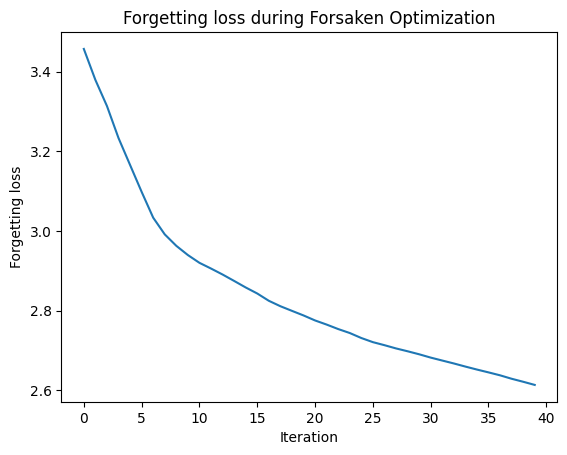

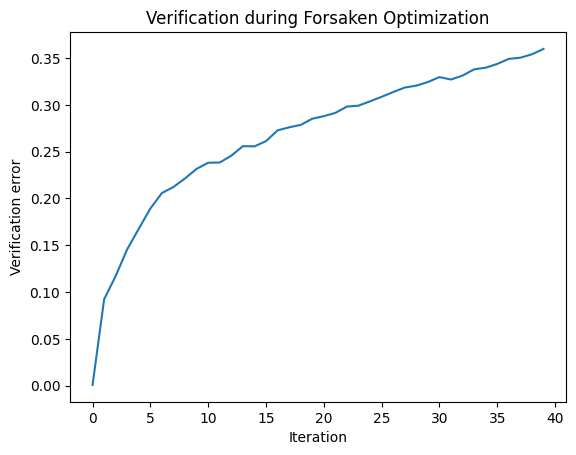

→ Accuracy D_f : 22.00%, Accuracy test : 83.19%

==== FORSAKEN avec T = 50 ====
Iteration 1, Loss: 3.4571, Verification Error: 0.0008
Iteration 2, Loss: 3.3793, Verification Error: 0.0923
Iteration 3, Loss: 3.3137, Verification Error: 0.1172
Iteration 4, Loss: 3.2333, Verification Error: 0.1458
Iteration 5, Loss: 3.1656, Verification Error: 0.1677
Iteration 6, Loss: 3.0981, Verification Error: 0.1893
Iteration 7, Loss: 3.0332, Verification Error: 0.2058
Iteration 8, Loss: 2.9913, Verification Error: 0.2123
Iteration 9, Loss: 2.9625, Verification Error: 0.2214
Iteration 10, Loss: 2.9394, Verification Error: 0.2316
Iteration 11, Loss: 2.9198, Verification Error: 0.2381
Iteration 12, Loss: 2.9055, Verification Error: 0.2384
Iteration 13, Loss: 2.8905, Verification Error: 0.2457
Iteration 14, Loss: 2.8744, Verification Error: 0.2558
Iteration 15, Loss: 2.8580, Verification Error: 0.2556
Iteration 16, Loss: 2.8428, Verification Error: 0.2612
Iteration 17, Loss: 2.8245, Verification Error: 0

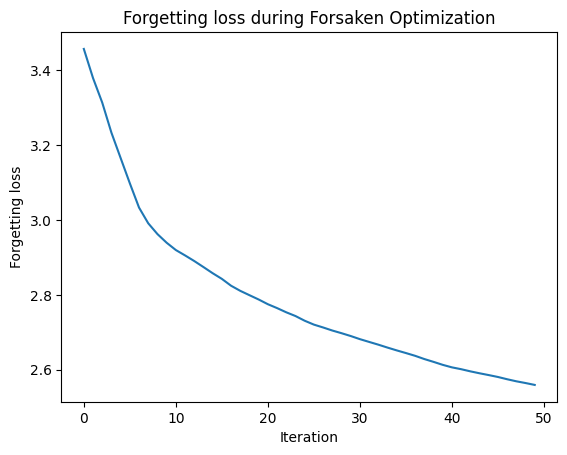

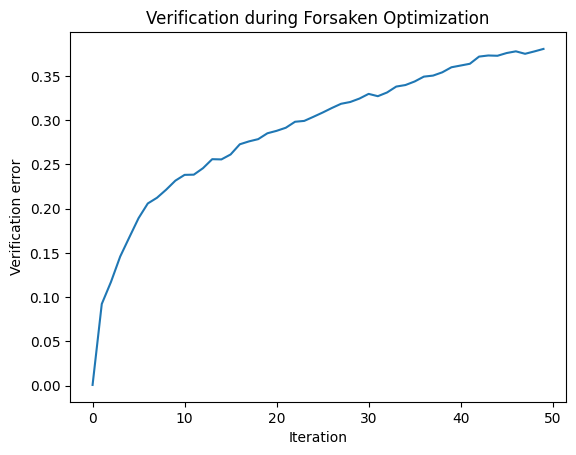

→ Accuracy D_f : 25.00%, Accuracy test : 82.44%

==== FORSAKEN avec T = 60 ====
Iteration 1, Loss: 3.4571, Verification Error: 0.0008
Iteration 2, Loss: 3.3793, Verification Error: 0.0923
Iteration 3, Loss: 3.3137, Verification Error: 0.1172
Iteration 4, Loss: 3.2333, Verification Error: 0.1458
Iteration 5, Loss: 3.1656, Verification Error: 0.1677
Iteration 6, Loss: 3.0981, Verification Error: 0.1893
Iteration 7, Loss: 3.0332, Verification Error: 0.2058
Iteration 8, Loss: 2.9913, Verification Error: 0.2123
Iteration 9, Loss: 2.9625, Verification Error: 0.2214
Iteration 10, Loss: 2.9394, Verification Error: 0.2316
Iteration 11, Loss: 2.9198, Verification Error: 0.2381
Iteration 12, Loss: 2.9055, Verification Error: 0.2384
Iteration 13, Loss: 2.8905, Verification Error: 0.2457
Iteration 14, Loss: 2.8744, Verification Error: 0.2558
Iteration 15, Loss: 2.8580, Verification Error: 0.2556
Iteration 16, Loss: 2.8428, Verification Error: 0.2612
Iteration 17, Loss: 2.8245, Verification Error: 0

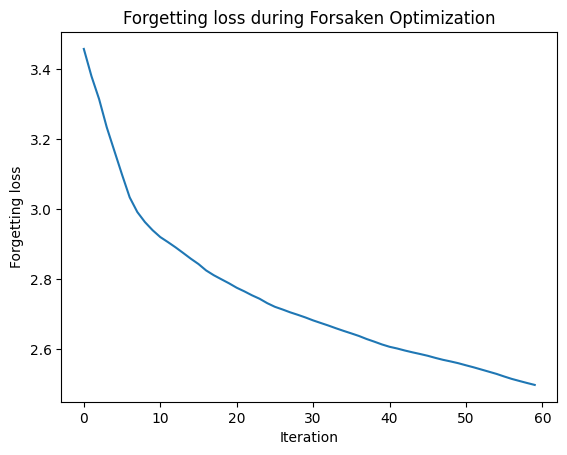

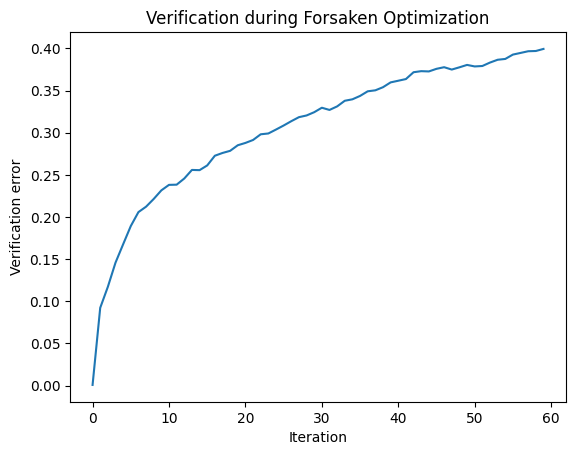

→ Accuracy D_f : 28.00%, Accuracy test : 81.74%

==== FORSAKEN avec T = 80 ====
Iteration 1, Loss: 3.4571, Verification Error: 0.0008
Iteration 2, Loss: 3.3793, Verification Error: 0.0923
Iteration 3, Loss: 3.3137, Verification Error: 0.1172
Iteration 4, Loss: 3.2333, Verification Error: 0.1458
Iteration 5, Loss: 3.1656, Verification Error: 0.1677
Iteration 6, Loss: 3.0981, Verification Error: 0.1893
Iteration 7, Loss: 3.0332, Verification Error: 0.2058
Iteration 8, Loss: 2.9913, Verification Error: 0.2123
Iteration 9, Loss: 2.9625, Verification Error: 0.2214
Iteration 10, Loss: 2.9394, Verification Error: 0.2316
Iteration 11, Loss: 2.9198, Verification Error: 0.2381
Iteration 12, Loss: 2.9055, Verification Error: 0.2384
Iteration 13, Loss: 2.8905, Verification Error: 0.2457
Iteration 14, Loss: 2.8744, Verification Error: 0.2558
Iteration 15, Loss: 2.8580, Verification Error: 0.2556
Iteration 16, Loss: 2.8428, Verification Error: 0.2612
Iteration 17, Loss: 2.8245, Verification Error: 0

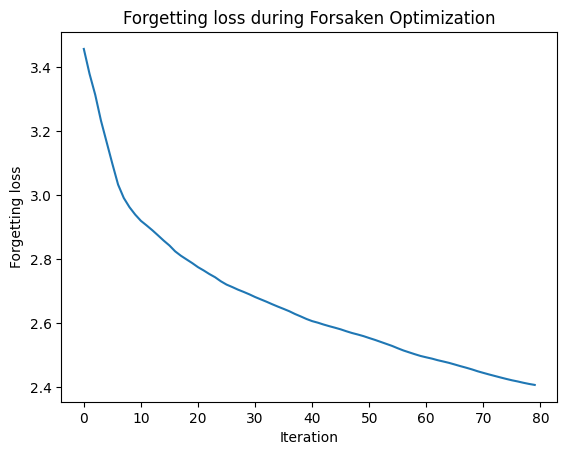

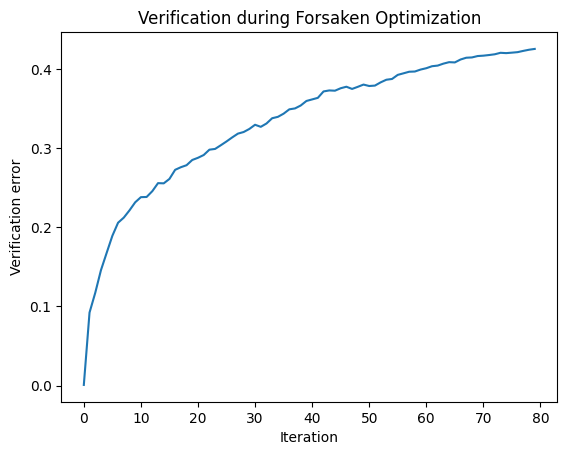

→ Accuracy D_f : 35.00%, Accuracy test : 80.81%


In [44]:
# Liste des T à tester
T_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 20, 30, 40, 50, 60, 80]

# Hyperparamètres FORSAKEN (constants)
lambda_ = 0.1
omega = 1.0
eta_mu = 0.2
xi = 1.0
optimizer_choice = 'LBFGS'

# Accuracies à stocker
accuracies_forget = []
accuracies_test = []

# Boucle sur les différentes valeurs de T
for T in T_values:
    print(f"\n==== FORSAKEN avec T = {T} ====")

    model_forsaken = forsaken_corrupted(
        f_theta_0=model_corrupted,  # modèle initial
        T=T,
        lambda_=lambda_,
        omega=omega,
        P=P,
        D_f=images_forget,  # batch du forget set
        eta_mu=eta_mu,
        xi=xi,
        optimizer=optimizer_choice
    )

    acc_forget = evaluate_model_corrupted(model_forsaken, forget_loader_corrupted)
    acc_test = evaluate_model_corrupted(model_forsaken, clean_test_loader)

    print(f"→ Accuracy D_f : {acc_forget:.2f}%, Accuracy test : {acc_test:.2f}%")

    accuracies_forget.append(acc_forget)
    accuracies_test.append(acc_test)

In [45]:
def plot_forsaken_vs_accuracy_label(T_values, acc_forget, acc_test):
    plt.figure(figsize=(10, 6))
    plt.plot(T_values, acc_forget, marker='o', label="Accuracy sur D_f (corrompu)", linewidth=2)
    plt.plot(T_values, acc_test, marker='s', label="Accuracy sur test set (clean)", linewidth=2)

    plt.xlabel("Nombre d'itérations FORSAKEN (T)")
    plt.ylabel("Accuracy (%)")
    plt.title("Effet de FORSAKEN sur l'accuracy en fonction de T")
    plt.grid(True)
    plt.legend()
    plt.ylim(0, 100)
    plt.xticks(T_values)
    plt.tight_layout()
    plt.show()


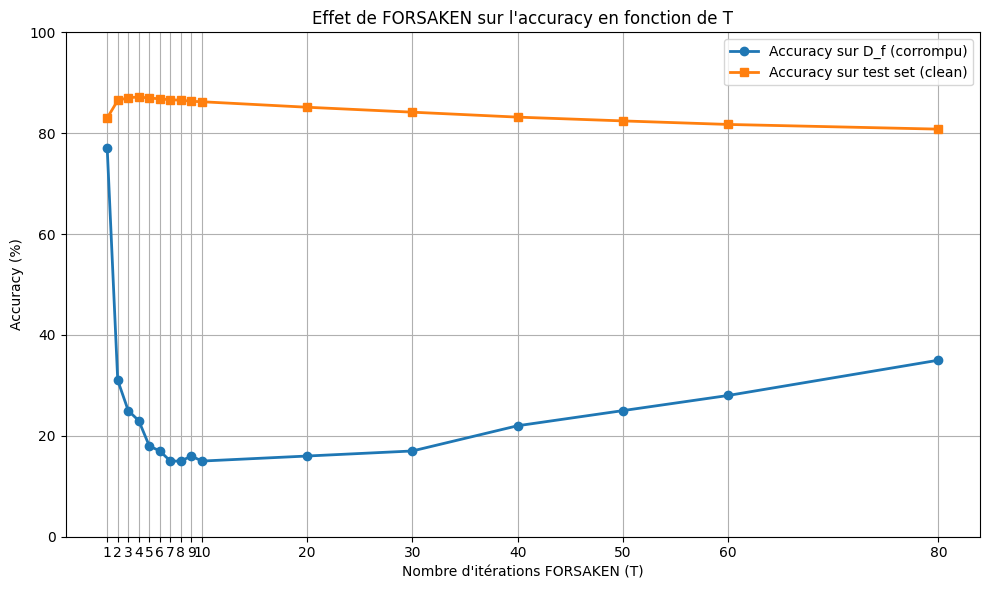

In [46]:
plot_forsaken_vs_accuracy_label(T_values, accuracies_forget, accuracies_test)

### CIFAR-10/MNIST

In [47]:

# ----------------------------
# 1. Définition des transformations
# ----------------------------
# Transformation pour MNIST : images en niveaux de gris (28x28) et normalisées
transform_mnist = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Transformation pour CIFAR-10 : conversion en niveaux de gris, redimensionnement en 28x28 et normalisation
transform_cifar = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize(28),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# ----------------------------
# 2. Création des datasets
# ----------------------------
# MNIST : on prend les 1000 premières images
mnist_dataset = datasets.MNIST(root="./data", train=True, transform=transform_mnist, download=True)
mnist_subset = Subset(mnist_dataset, list(range(1000)))

# CIFAR-10 avec labels aléatoires
class CIFAR10RandomLabels(datasets.CIFAR10):
    def __init__(self, *args, **kwargs):
        super(CIFAR10RandomLabels, self).__init__(*args, **kwargs)
        random.seed(42)
        self.targets = [random.randint(0, 9) for _ in range(len(self.data))]

cifar_dataset = CIFAR10RandomLabels(root="./data", train=True, transform=transform_cifar, download=True)
# On ne garde que 200 images de CIFAR-10
cifar_subset = Subset(cifar_dataset, list(range(200)))

# D_f correspond ici au forget set (les images CIFAR-10)
forget_loader = DataLoader(cifar_subset, batch_size=64, shuffle=False)

# Création du dataset combiné (1000 MNIST + 200 CIFAR-10)
combined_dataset = ConcatDataset([mnist_subset, cifar_subset])
combined_loader = DataLoader(combined_dataset, batch_size=64, shuffle=True)

# Création du dataset clean (uniquement MNIST, on utilise le test set ici)
clean_mnist_dataset = datasets.MNIST(root="./data", train=False, transform=transform_mnist, download=True)
clean_mnist_loader = DataLoader(clean_mnist_dataset, batch_size=64, shuffle=False)


print(f"Nombre total d'images dans le dataset combiné : {len(combined_dataset)}")


Nombre total d'images dans le dataset combiné : 1200


In [48]:

# ====================================
# 4. Entraînement, utilisation de FORSAKEN et évaluation
# ====================================

# Initialisation et entraînement du modèle sur le dataset combiné
model_original = FullyConnectedNN()
print("Entraînement du modèle sur le dataset combiné (1000 MNIST + 200 CIFAR‑10)...")
train_model(model_original, combined_loader, lr=0.01, epochs=200)
    
# Évaluation du modèle entraîné (baseline)
acc_combined_baseline = evaluate_model(model_original, combined_loader)
acc_forget_baseline = evaluate_model(model_original, forget_loader)
    
print(f" Avant FORSAKEN  - Accuracy sur dataset combiné : {acc_combined_baseline:.2f}%")
print(f"Avant FORSAKEN - Accuracy sur forget set (CIFAR‑10) : {acc_forget_baseline:.2f}%")
    
# Préparation du batch du forget set à utiliser dans FORSAKEN
images_forget, labels_forget = next(iter(forget_loader))
# Cible P (distribution uniforme sur 10 classes)
P = torch.full((images_forget.size(0), 10), 1/10)
    


Entraînement du modèle sur le dataset combiné (1000 MNIST + 200 CIFAR‑10)...
Epoch 1/200, Loss: 2.2906
Epoch 2/200, Loss: 2.2536
Epoch 3/200, Loss: 2.2131
Epoch 4/200, Loss: 2.1675
Epoch 5/200, Loss: 2.1119
Epoch 6/200, Loss: 2.0454
Epoch 7/200, Loss: 1.9646
Epoch 8/200, Loss: 1.8690
Epoch 9/200, Loss: 1.7592
Epoch 10/200, Loss: 1.6437
Epoch 11/200, Loss: 1.5247
Epoch 12/200, Loss: 1.4125
Epoch 13/200, Loss: 1.3136
Epoch 14/200, Loss: 1.2260
Epoch 15/200, Loss: 1.1488
Epoch 16/200, Loss: 1.0850
Epoch 17/200, Loss: 1.0317
Epoch 18/200, Loss: 0.9857
Epoch 19/200, Loss: 0.9492
Epoch 20/200, Loss: 0.9160
Epoch 21/200, Loss: 0.8835
Epoch 22/200, Loss: 0.8587
Epoch 23/200, Loss: 0.8342
Epoch 24/200, Loss: 0.8150
Epoch 25/200, Loss: 0.7928
Epoch 26/200, Loss: 0.7758
Epoch 27/200, Loss: 0.7609
Epoch 28/200, Loss: 0.7442
Epoch 29/200, Loss: 0.7331
Epoch 30/200, Loss: 0.7155
Epoch 31/200, Loss: 0.7024
Epoch 32/200, Loss: 0.6924
Epoch 33/200, Loss: 0.6853
Epoch 34/200, Loss: 0.6712
Epoch 35/200, 


Application de la procédure FORSAKEN pour oublier le forget set...


C:\Users\mathi\AppData\Local\Temp\ipykernel_19408\2729838387.py:40: FutureWarning: `torch.nn.utils.stateless.functional_call` is deprecated as of PyTorch 2.0 and will be removed in a future version of PyTorch. Please use `torch.func.functional_call` instead which is a drop-in replacement.
  outputs = functional_call(model_t, new_params, D_f)


Iteration 1, Loss: 0.1694, Verification Error: 0.4514
Iteration 2, Loss: 0.0129, Verification Error: 0.8389
Fin de la procédure Forsaken.


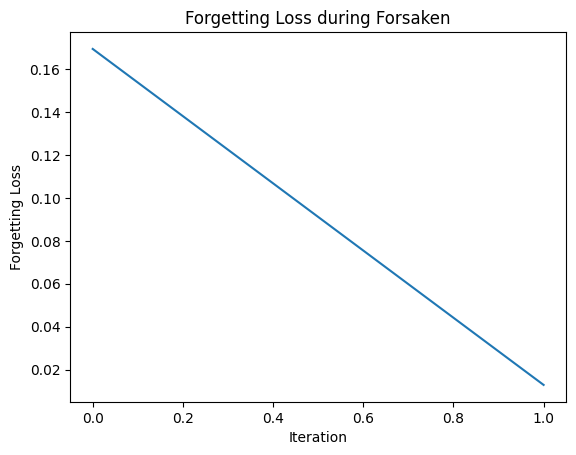

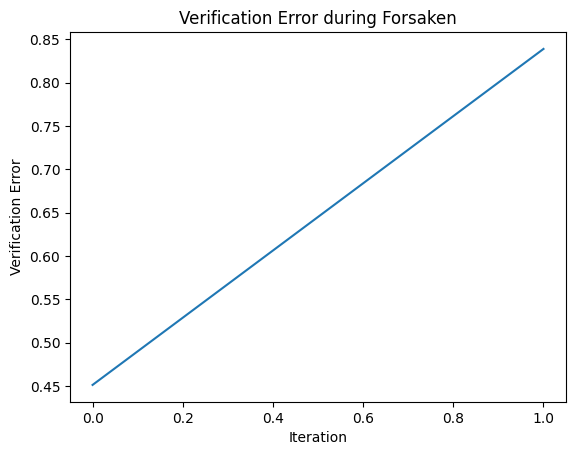

Après FORSAKEN - Accuracy sur dataset combiné : 94.08%
Après FORSAKEN - Accuracy sur forget set (CIFAR‑10) : 65.00%
 Avant FORSAKEN  - Accuracy sur dataset combiné : 97.33%
Avant FORSAKEN - Accuracy sur forget set (CIFAR‑10) : 84.00%


In [49]:
# Paramètres pour FORSAKEN
T = 2         # nombre d'itérations
lambda_ = 0   # coefficient de régularisation (peut être ajusté)
omega = 1.0    # facteur de pondération
eta_mu = 0.1   # learning rate pour mu
xi = 0.1       # scalaire de mise à jour
optimizer_choice = 'LBFGS'
    
print("\nApplication de la procédure FORSAKEN pour oublier le forget set...")
model_forsaken = forsaken_CIFAR(
        f_theta_0=model_original,
        T=T,
        lambda_=lambda_,
        omega=omega,
        P=P,
        D_f=images_forget,  # Batch du forget set
        eta_mu=eta_mu,
        xi=xi,
        optimizer=optimizer_choice
    )
    
    # Évaluation du modèle après FORSAKEN
acc_combined_forsaken = evaluate_model(model_forsaken, combined_loader)
acc_forget_forsaken = evaluate_model(model_forsaken, forget_loader)
print(f"Après FORSAKEN - Accuracy sur dataset combiné : {acc_combined_forsaken:.2f}%")
print(f"Après FORSAKEN - Accuracy sur forget set (CIFAR‑10) : {acc_forget_forsaken:.2f}%")

print(f" Avant FORSAKEN  - Accuracy sur dataset combiné : {acc_combined_baseline:.2f}%")
print(f"Avant FORSAKEN - Accuracy sur forget set (CIFAR‑10) : {acc_forget_baseline:.2f}%")

In [50]:
# 1. Définir un nouveau modèle
model_retrained = FullyConnectedNN()

# 2. Utiliser uniquement les données MNIST (retain set)
retain_loader = DataLoader(mnist_subset, batch_size=64, shuffle=True)

# 4. Entraîner
train_model(model_retrained, retain_loader, lr=0.01, epochs=200)


Epoch 1/200, Loss: 2.2993
Epoch 2/200, Loss: 2.2419
Epoch 3/200, Loss: 2.1826
Epoch 4/200, Loss: 2.1142
Epoch 5/200, Loss: 2.0354
Epoch 6/200, Loss: 1.9379
Epoch 7/200, Loss: 1.8245
Epoch 8/200, Loss: 1.6936
Epoch 9/200, Loss: 1.5547
Epoch 10/200, Loss: 1.4072
Epoch 11/200, Loss: 1.2685
Epoch 12/200, Loss: 1.1410
Epoch 13/200, Loss: 1.0307
Epoch 14/200, Loss: 0.9358
Epoch 15/200, Loss: 0.8510
Epoch 16/200, Loss: 0.7841
Epoch 17/200, Loss: 0.7301
Epoch 18/200, Loss: 0.6817
Epoch 19/200, Loss: 0.6369
Epoch 20/200, Loss: 0.6028
Epoch 21/200, Loss: 0.5708
Epoch 22/200, Loss: 0.5421
Epoch 23/200, Loss: 0.5148
Epoch 24/200, Loss: 0.4901
Epoch 25/200, Loss: 0.4770
Epoch 26/200, Loss: 0.4577
Epoch 27/200, Loss: 0.4362
Epoch 28/200, Loss: 0.4190
Epoch 29/200, Loss: 0.4048
Epoch 30/200, Loss: 0.3930
Epoch 31/200, Loss: 0.3834
Epoch 32/200, Loss: 0.3692
Epoch 33/200, Loss: 0.3576
Epoch 34/200, Loss: 0.3501
Epoch 35/200, Loss: 0.3359
Epoch 36/200, Loss: 0.3274
Epoch 37/200, Loss: 0.3234
Epoch 38/2

In [51]:
accuracies_CIFAR = get_accuracy(
    model_forsaken=model_forsaken,
    model_target=model_original,
    model_retrained=model_retrained,
    forget_loader=forget_loader,
    test_loader=clean_mnist_loader
)


Accuracy sur D_f après Forsaken : 65.00%
Accuracy sur D_f sans Forsaken : 84.00%
Accuracy sur D_f avec réentraînement: 12.50%
Accuracy sur base de test après Forsaken : 86.12%
Accuracy sur base de test sans Forsaken : 86.97%
Accuracy sur base de test avec réentraînement : 87.70%


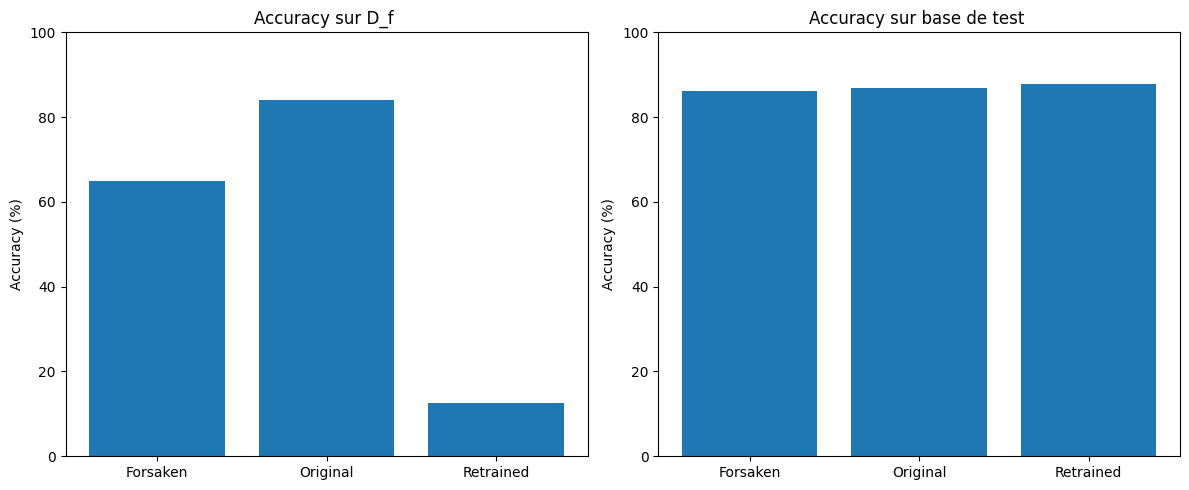

In [52]:
plot_hist(accuracies_CIFAR)


==== FORSAKEN avec T = 1 ====


C:\Users\mathi\AppData\Local\Temp\ipykernel_19408\2729838387.py:40: FutureWarning: `torch.nn.utils.stateless.functional_call` is deprecated as of PyTorch 2.0 and will be removed in a future version of PyTorch. Please use `torch.func.functional_call` instead which is a drop-in replacement.
  outputs = functional_call(model_t, new_params, D_f)


Iteration 1, Loss: 0.1694, Verification Error: 0.4514
Fin de la procédure Forsaken.


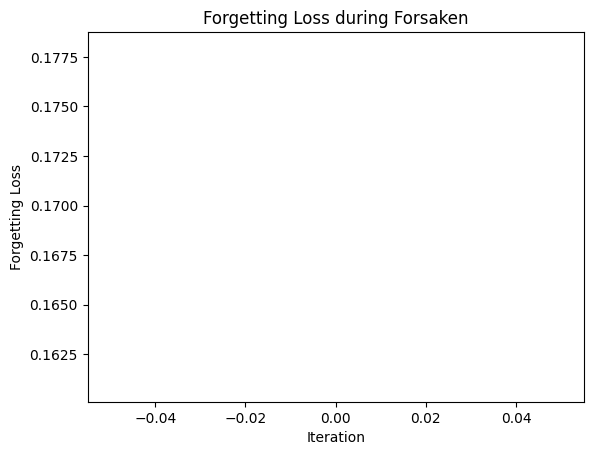

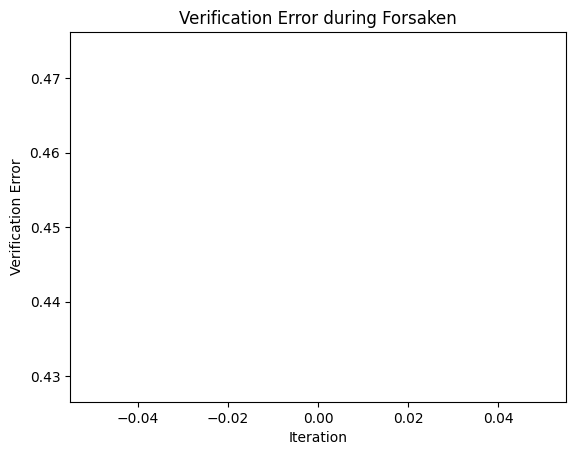

→ Accuracy D_f : 71.50%, Accuracy test : 86.45%

==== FORSAKEN avec T = 2 ====
Iteration 1, Loss: 0.1694, Verification Error: 0.4514
Iteration 2, Loss: 0.0129, Verification Error: 0.8389
Fin de la procédure Forsaken.


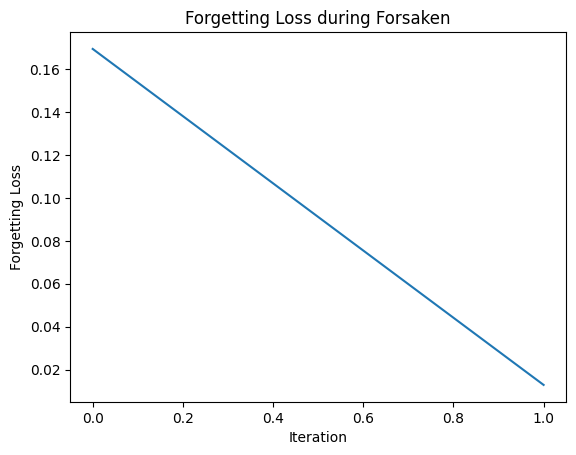

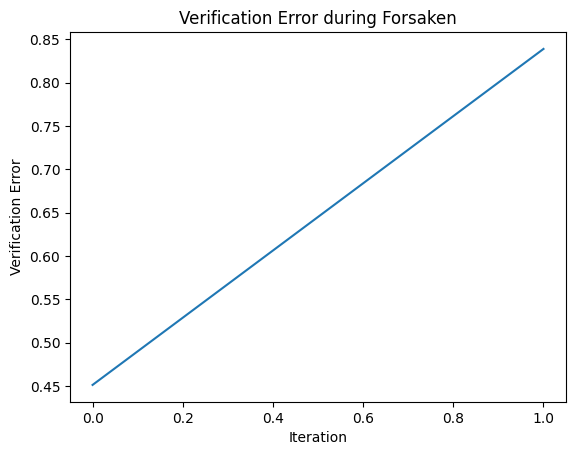

→ Accuracy D_f : 65.00%, Accuracy test : 86.12%

==== FORSAKEN avec T = 3 ====
Iteration 1, Loss: 0.1694, Verification Error: 0.4514
Iteration 2, Loss: 0.0129, Verification Error: 0.8389
Iteration 3, Loss: 0.0020, Verification Error: 1.0895
Fin de la procédure Forsaken.


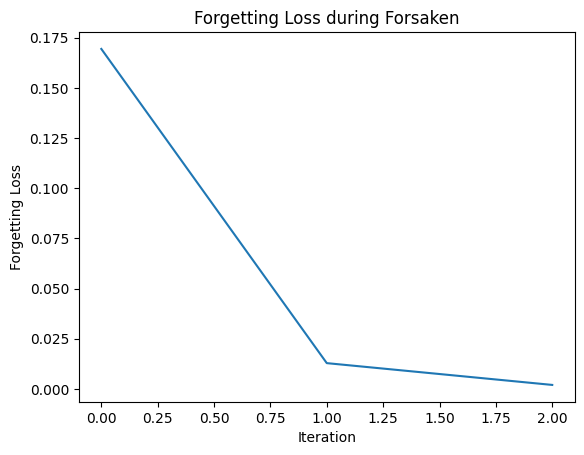

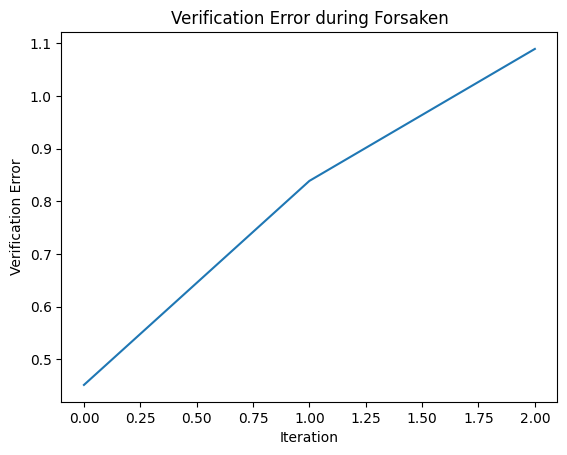

→ Accuracy D_f : 53.50%, Accuracy test : 86.07%

==== FORSAKEN avec T = 4 ====
Iteration 1, Loss: 0.1694, Verification Error: 0.4514
Iteration 2, Loss: 0.0129, Verification Error: 0.8389
Iteration 3, Loss: 0.0020, Verification Error: 1.0895
Iteration 4, Loss: 0.0005, Verification Error: 1.2667
Fin de la procédure Forsaken.


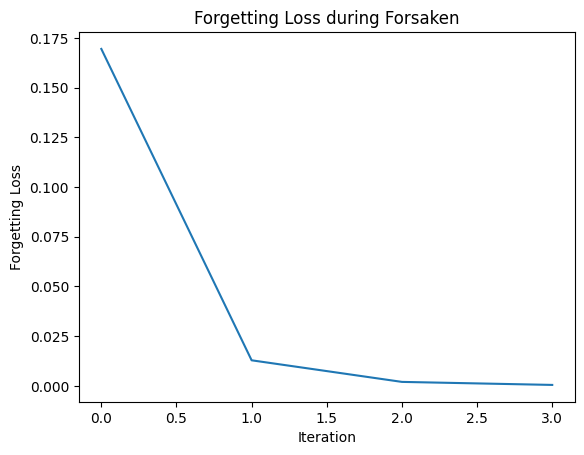

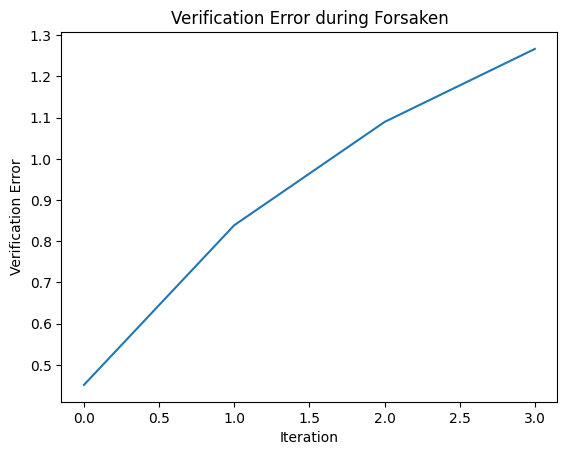

→ Accuracy D_f : 48.50%, Accuracy test : 85.84%

==== FORSAKEN avec T = 5 ====
Iteration 1, Loss: 0.1694, Verification Error: 0.4514
Iteration 2, Loss: 0.0129, Verification Error: 0.8389
Iteration 3, Loss: 0.0020, Verification Error: 1.0895
Iteration 4, Loss: 0.0005, Verification Error: 1.2667
Iteration 5, Loss: 0.0002, Verification Error: 1.3424
Fin de la procédure Forsaken.


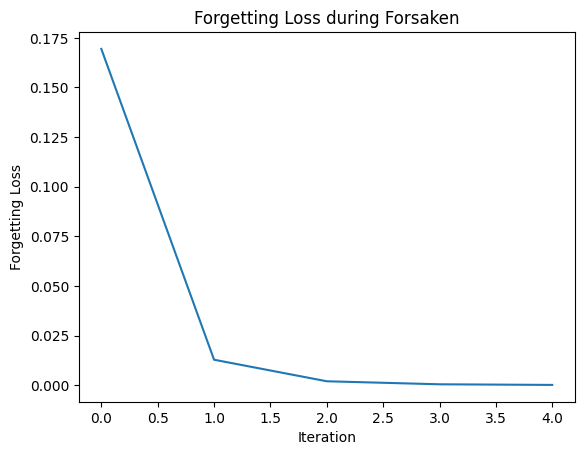

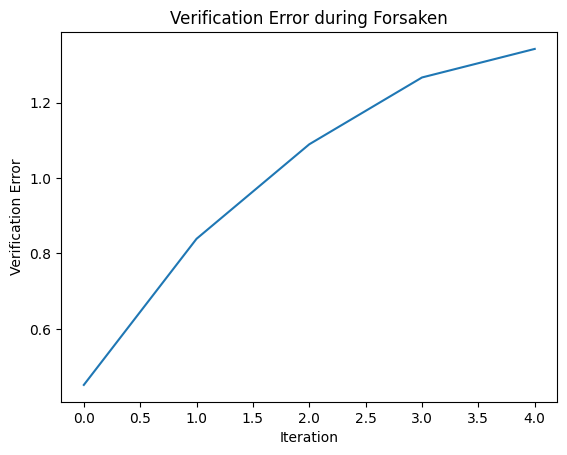

→ Accuracy D_f : 45.00%, Accuracy test : 85.85%

==== FORSAKEN avec T = 6 ====
Iteration 1, Loss: 0.1694, Verification Error: 0.4514
Iteration 2, Loss: 0.0129, Verification Error: 0.8389
Iteration 3, Loss: 0.0020, Verification Error: 1.0895
Iteration 4, Loss: 0.0005, Verification Error: 1.2667
Iteration 5, Loss: 0.0002, Verification Error: 1.3424
Iteration 6, Loss: 0.0001, Verification Error: 1.3781
Fin de la procédure Forsaken.


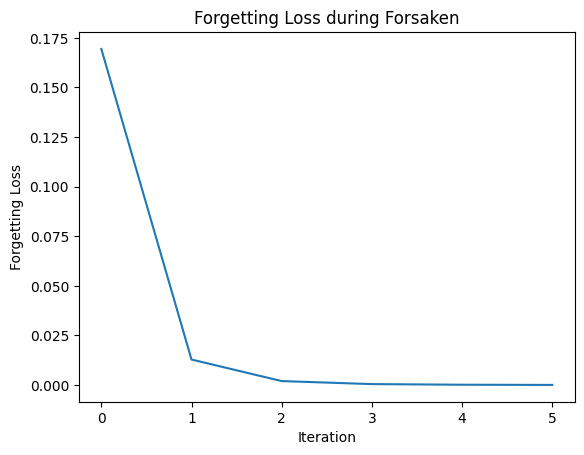

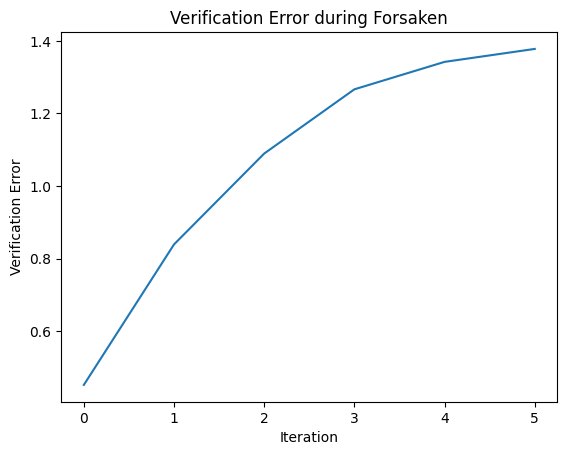

→ Accuracy D_f : 44.00%, Accuracy test : 85.84%

==== FORSAKEN avec T = 7 ====
Iteration 1, Loss: 0.1694, Verification Error: 0.4514
Iteration 2, Loss: 0.0129, Verification Error: 0.8389
Iteration 3, Loss: 0.0020, Verification Error: 1.0895
Iteration 4, Loss: 0.0005, Verification Error: 1.2667
Iteration 5, Loss: 0.0002, Verification Error: 1.3424
Iteration 6, Loss: 0.0001, Verification Error: 1.3781
Iteration 7, Loss: 0.0000, Verification Error: 1.4030
Fin de la procédure Forsaken.


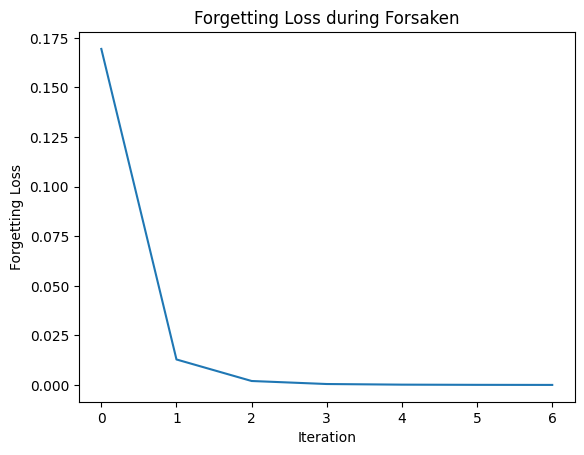

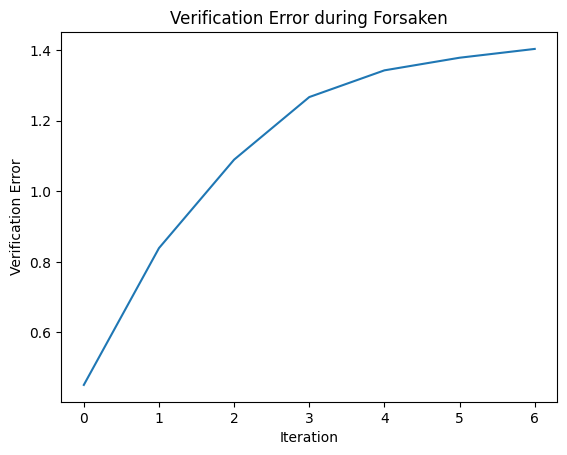

→ Accuracy D_f : 42.50%, Accuracy test : 85.73%

==== FORSAKEN avec T = 8 ====
Iteration 1, Loss: 0.1694, Verification Error: 0.4514
Iteration 2, Loss: 0.0129, Verification Error: 0.8389
Iteration 3, Loss: 0.0020, Verification Error: 1.0895
Iteration 4, Loss: 0.0005, Verification Error: 1.2667
Iteration 5, Loss: 0.0002, Verification Error: 1.3424
Iteration 6, Loss: 0.0001, Verification Error: 1.3781
Iteration 7, Loss: 0.0000, Verification Error: 1.4030
Iteration 8, Loss: 0.0000, Verification Error: 1.4191
Fin de la procédure Forsaken.


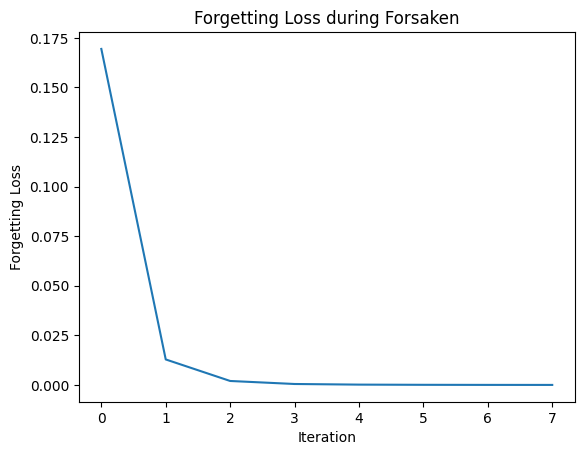

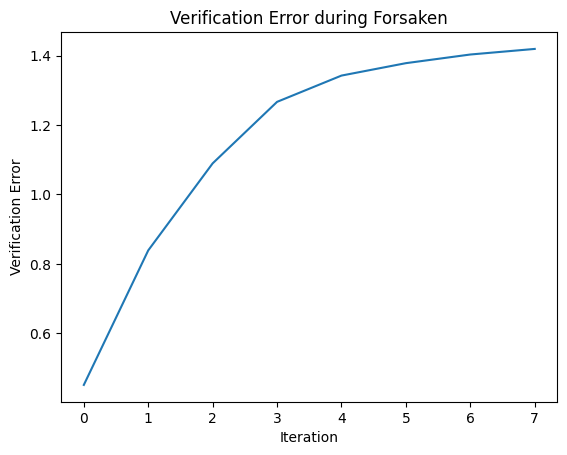

→ Accuracy D_f : 42.50%, Accuracy test : 85.75%

==== FORSAKEN avec T = 9 ====
Iteration 1, Loss: 0.1694, Verification Error: 0.4514
Iteration 2, Loss: 0.0129, Verification Error: 0.8389
Iteration 3, Loss: 0.0020, Verification Error: 1.0895
Iteration 4, Loss: 0.0005, Verification Error: 1.2667
Iteration 5, Loss: 0.0002, Verification Error: 1.3424
Iteration 6, Loss: 0.0001, Verification Error: 1.3781
Iteration 7, Loss: 0.0000, Verification Error: 1.4030
Iteration 8, Loss: 0.0000, Verification Error: 1.4191
Iteration 9, Loss: 0.0000, Verification Error: 1.4267
Fin de la procédure Forsaken.


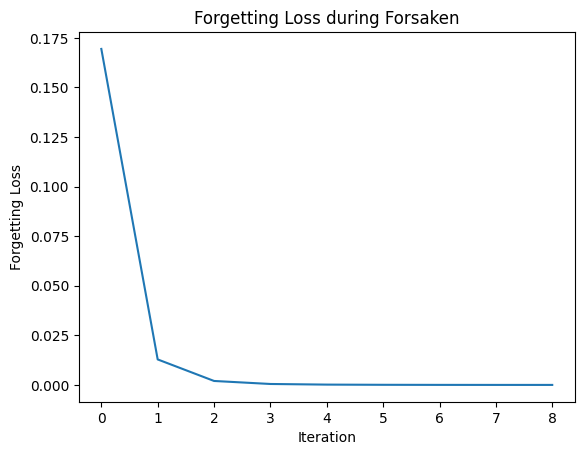

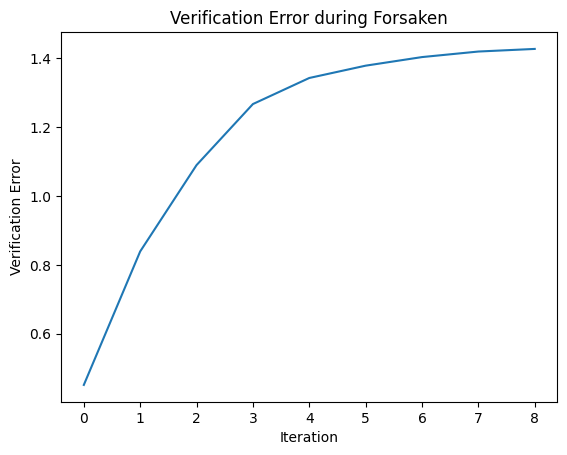

→ Accuracy D_f : 41.00%, Accuracy test : 85.75%

==== FORSAKEN avec T = 10 ====
Iteration 1, Loss: 0.1694, Verification Error: 0.4514
Iteration 2, Loss: 0.0129, Verification Error: 0.8389
Iteration 3, Loss: 0.0020, Verification Error: 1.0895
Iteration 4, Loss: 0.0005, Verification Error: 1.2667
Iteration 5, Loss: 0.0002, Verification Error: 1.3424
Iteration 6, Loss: 0.0001, Verification Error: 1.3781
Iteration 7, Loss: 0.0000, Verification Error: 1.4030
Iteration 8, Loss: 0.0000, Verification Error: 1.4191
Iteration 9, Loss: 0.0000, Verification Error: 1.4267
Iteration 10, Loss: 0.0000, Verification Error: 1.4316
Fin de la procédure Forsaken.


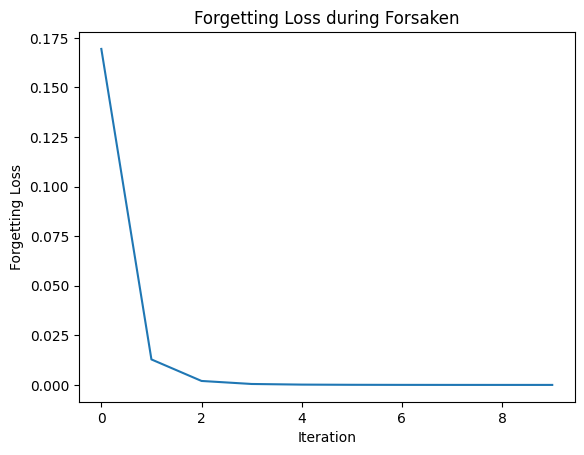

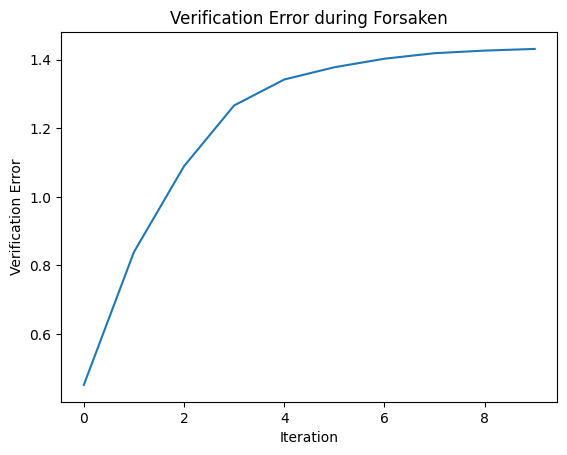

→ Accuracy D_f : 42.00%, Accuracy test : 85.73%

==== FORSAKEN avec T = 20 ====
Iteration 1, Loss: 0.1694, Verification Error: 0.4514
Iteration 2, Loss: 0.0129, Verification Error: 0.8389
Iteration 3, Loss: 0.0020, Verification Error: 1.0895
Iteration 4, Loss: 0.0005, Verification Error: 1.2667
Iteration 5, Loss: 0.0002, Verification Error: 1.3424
Iteration 6, Loss: 0.0001, Verification Error: 1.3781
Iteration 7, Loss: 0.0000, Verification Error: 1.4030
Iteration 8, Loss: 0.0000, Verification Error: 1.4191
Iteration 9, Loss: 0.0000, Verification Error: 1.4267
Iteration 10, Loss: 0.0000, Verification Error: 1.4316
Iteration 11, Loss: 0.0000, Verification Error: 1.4368
Iteration 12, Loss: 0.0000, Verification Error: 1.4402
Iteration 13, Loss: 0.0000, Verification Error: 1.4423
Iteration 14, Loss: 0.0000, Verification Error: 1.4439
Iteration 15, Loss: 0.0000, Verification Error: 1.4453
Iteration 16, Loss: 0.0000, Verification Error: 1.4469
Iteration 17, Loss: 0.0000, Verification Error: 1

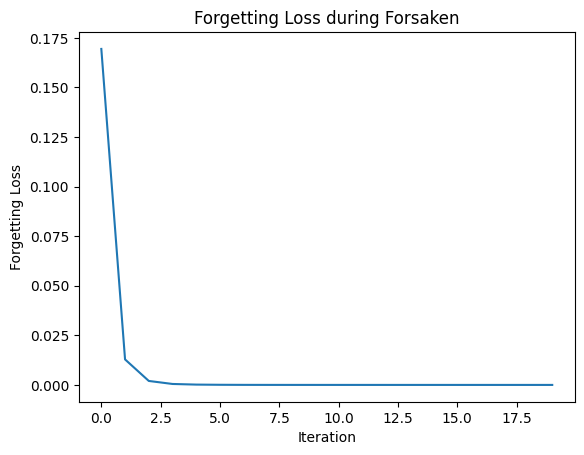

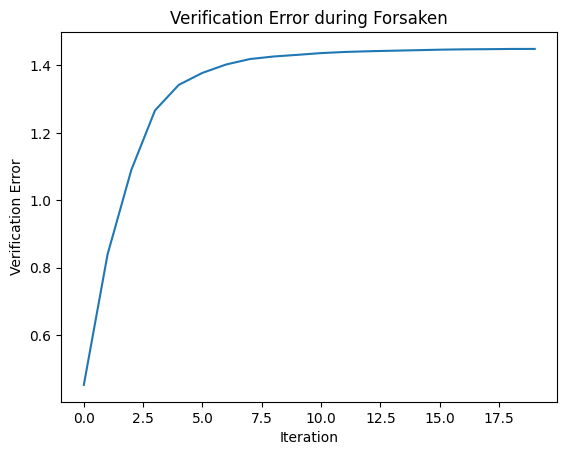

→ Accuracy D_f : 40.00%, Accuracy test : 85.66%

==== FORSAKEN avec T = 30 ====
Iteration 1, Loss: 0.1694, Verification Error: 0.4514
Iteration 2, Loss: 0.0129, Verification Error: 0.8389
Iteration 3, Loss: 0.0020, Verification Error: 1.0895
Iteration 4, Loss: 0.0005, Verification Error: 1.2667
Iteration 5, Loss: 0.0002, Verification Error: 1.3424
Iteration 6, Loss: 0.0001, Verification Error: 1.3781
Iteration 7, Loss: 0.0000, Verification Error: 1.4030
Iteration 8, Loss: 0.0000, Verification Error: 1.4191
Iteration 9, Loss: 0.0000, Verification Error: 1.4267
Iteration 10, Loss: 0.0000, Verification Error: 1.4316
Iteration 11, Loss: 0.0000, Verification Error: 1.4368
Iteration 12, Loss: 0.0000, Verification Error: 1.4402
Iteration 13, Loss: 0.0000, Verification Error: 1.4423
Iteration 14, Loss: 0.0000, Verification Error: 1.4439
Iteration 15, Loss: 0.0000, Verification Error: 1.4453
Iteration 16, Loss: 0.0000, Verification Error: 1.4469
Iteration 17, Loss: 0.0000, Verification Error: 1

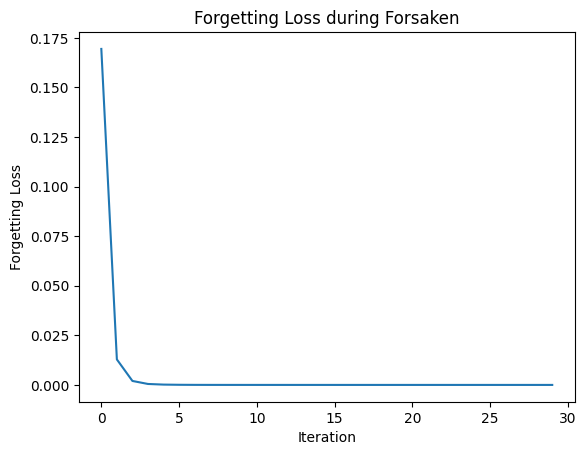

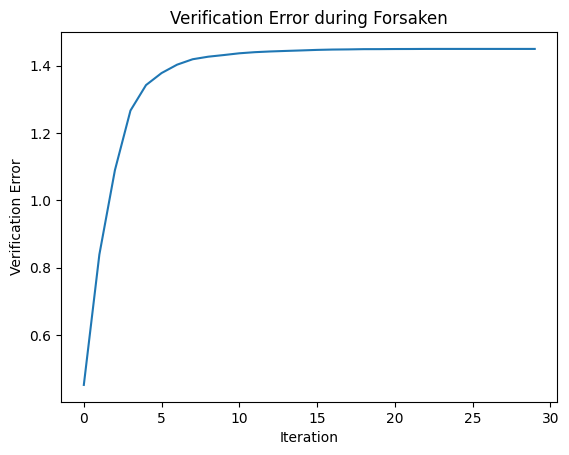

→ Accuracy D_f : 41.00%, Accuracy test : 85.67%

==== FORSAKEN avec T = 40 ====
Iteration 1, Loss: 0.1694, Verification Error: 0.4514
Iteration 2, Loss: 0.0129, Verification Error: 0.8389
Iteration 3, Loss: 0.0020, Verification Error: 1.0895
Iteration 4, Loss: 0.0005, Verification Error: 1.2667
Iteration 5, Loss: 0.0002, Verification Error: 1.3424
Iteration 6, Loss: 0.0001, Verification Error: 1.3781
Iteration 7, Loss: 0.0000, Verification Error: 1.4030
Iteration 8, Loss: 0.0000, Verification Error: 1.4191
Iteration 9, Loss: 0.0000, Verification Error: 1.4267
Iteration 10, Loss: 0.0000, Verification Error: 1.4316
Iteration 11, Loss: 0.0000, Verification Error: 1.4368
Iteration 12, Loss: 0.0000, Verification Error: 1.4402
Iteration 13, Loss: 0.0000, Verification Error: 1.4423
Iteration 14, Loss: 0.0000, Verification Error: 1.4439
Iteration 15, Loss: 0.0000, Verification Error: 1.4453
Iteration 16, Loss: 0.0000, Verification Error: 1.4469
Iteration 17, Loss: 0.0000, Verification Error: 1

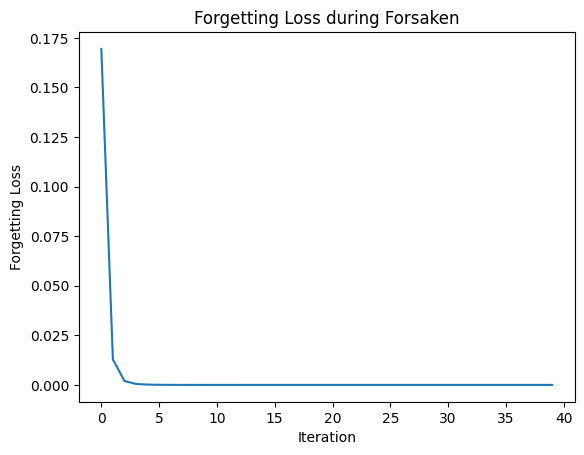

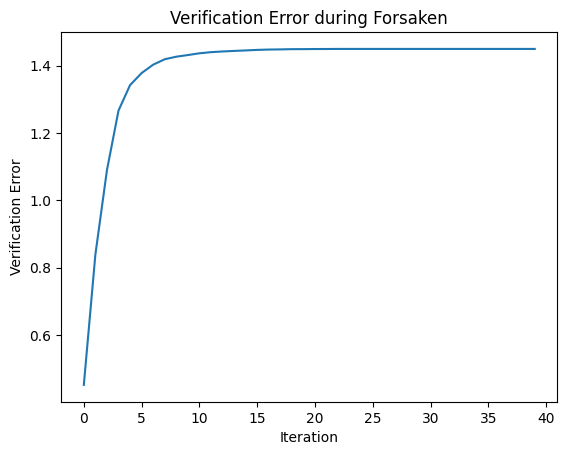

→ Accuracy D_f : 41.00%, Accuracy test : 85.67%

==== FORSAKEN avec T = 50 ====
Iteration 1, Loss: 0.1694, Verification Error: 0.4514
Iteration 2, Loss: 0.0129, Verification Error: 0.8389
Iteration 3, Loss: 0.0020, Verification Error: 1.0895
Iteration 4, Loss: 0.0005, Verification Error: 1.2667
Iteration 5, Loss: 0.0002, Verification Error: 1.3424
Iteration 6, Loss: 0.0001, Verification Error: 1.3781
Iteration 7, Loss: 0.0000, Verification Error: 1.4030
Iteration 8, Loss: 0.0000, Verification Error: 1.4191
Iteration 9, Loss: 0.0000, Verification Error: 1.4267
Iteration 10, Loss: 0.0000, Verification Error: 1.4316
Iteration 11, Loss: 0.0000, Verification Error: 1.4368
Iteration 12, Loss: 0.0000, Verification Error: 1.4402
Iteration 13, Loss: 0.0000, Verification Error: 1.4423
Iteration 14, Loss: 0.0000, Verification Error: 1.4439
Iteration 15, Loss: 0.0000, Verification Error: 1.4453
Iteration 16, Loss: 0.0000, Verification Error: 1.4469
Iteration 17, Loss: 0.0000, Verification Error: 1

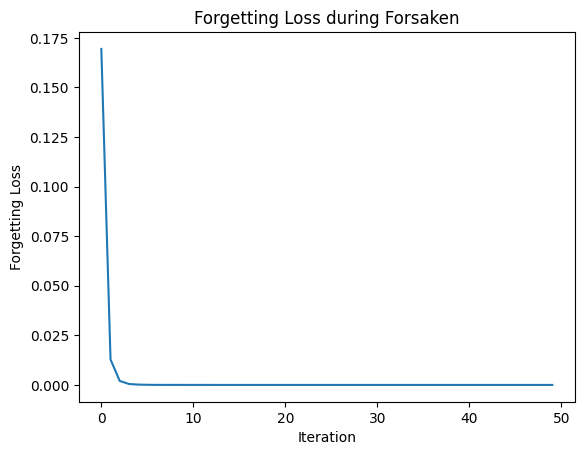

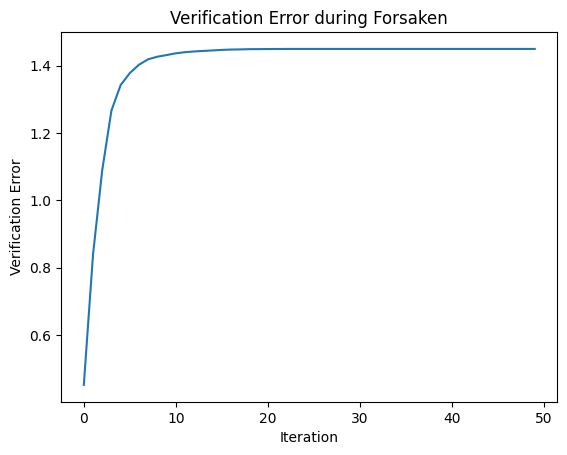

→ Accuracy D_f : 41.00%, Accuracy test : 85.67%

==== FORSAKEN avec T = 60 ====
Iteration 1, Loss: 0.1694, Verification Error: 0.4514
Iteration 2, Loss: 0.0129, Verification Error: 0.8389
Iteration 3, Loss: 0.0020, Verification Error: 1.0895
Iteration 4, Loss: 0.0005, Verification Error: 1.2667
Iteration 5, Loss: 0.0002, Verification Error: 1.3424
Iteration 6, Loss: 0.0001, Verification Error: 1.3781
Iteration 7, Loss: 0.0000, Verification Error: 1.4030
Iteration 8, Loss: 0.0000, Verification Error: 1.4191
Iteration 9, Loss: 0.0000, Verification Error: 1.4267
Iteration 10, Loss: 0.0000, Verification Error: 1.4316
Iteration 11, Loss: 0.0000, Verification Error: 1.4368
Iteration 12, Loss: 0.0000, Verification Error: 1.4402
Iteration 13, Loss: 0.0000, Verification Error: 1.4423
Iteration 14, Loss: 0.0000, Verification Error: 1.4439
Iteration 15, Loss: 0.0000, Verification Error: 1.4453
Iteration 16, Loss: 0.0000, Verification Error: 1.4469
Iteration 17, Loss: 0.0000, Verification Error: 1

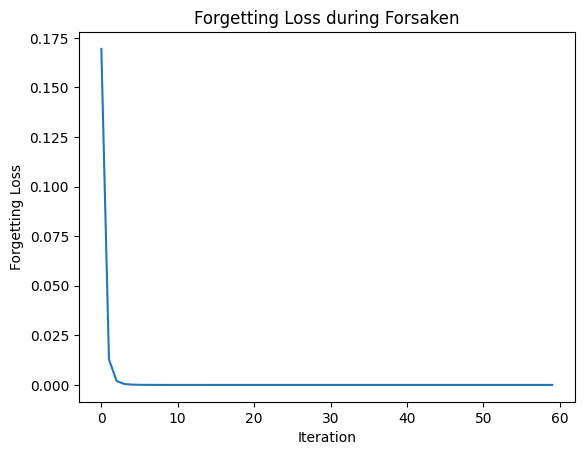

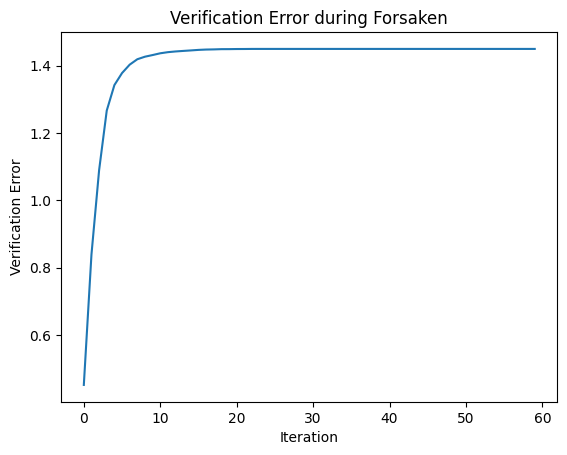

→ Accuracy D_f : 41.00%, Accuracy test : 85.67%

==== FORSAKEN avec T = 80 ====
Iteration 1, Loss: 0.1694, Verification Error: 0.4514
Iteration 2, Loss: 0.0129, Verification Error: 0.8389
Iteration 3, Loss: 0.0020, Verification Error: 1.0895
Iteration 4, Loss: 0.0005, Verification Error: 1.2667
Iteration 5, Loss: 0.0002, Verification Error: 1.3424
Iteration 6, Loss: 0.0001, Verification Error: 1.3781
Iteration 7, Loss: 0.0000, Verification Error: 1.4030
Iteration 8, Loss: 0.0000, Verification Error: 1.4191
Iteration 9, Loss: 0.0000, Verification Error: 1.4267
Iteration 10, Loss: 0.0000, Verification Error: 1.4316
Iteration 11, Loss: 0.0000, Verification Error: 1.4368
Iteration 12, Loss: 0.0000, Verification Error: 1.4402
Iteration 13, Loss: 0.0000, Verification Error: 1.4423
Iteration 14, Loss: 0.0000, Verification Error: 1.4439
Iteration 15, Loss: 0.0000, Verification Error: 1.4453
Iteration 16, Loss: 0.0000, Verification Error: 1.4469
Iteration 17, Loss: 0.0000, Verification Error: 1

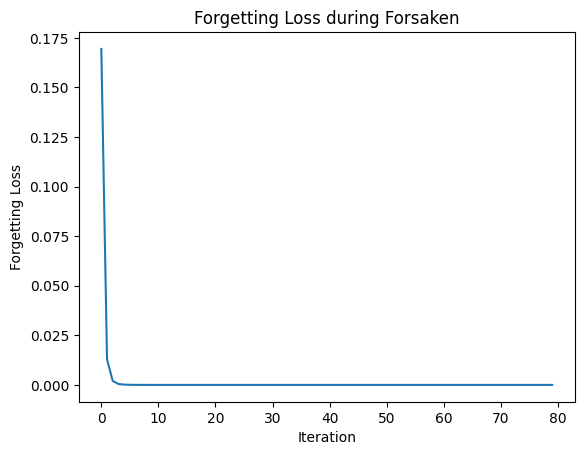

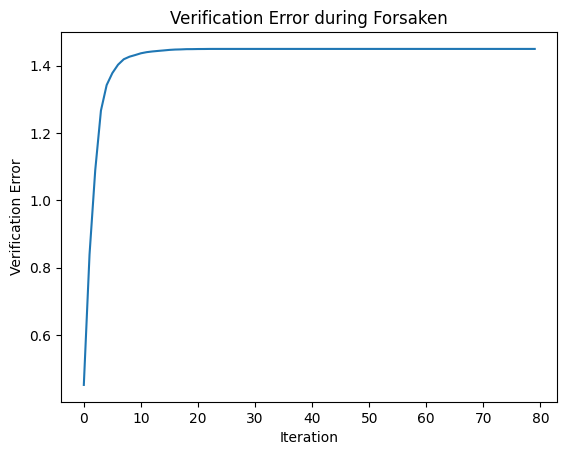

→ Accuracy D_f : 41.00%, Accuracy test : 85.67%


In [53]:
import matplotlib.pyplot as plt

# Plages d’itérations T (de 1 à 10)
T_values = [1,2,3,4,5,6,7,8,9,10,20,30,40,50,60,80]

# Accuracies à stocker
accuracies_forget = []
accuracies_test = []

for T in T_values:
    print(f"\n==== FORSAKEN avec T = {T} ====")
    
    model_forsaken = forsaken_CIFAR(
        f_theta_0=model_original,
        T=T,
        lambda_=lambda_,
        omega=omega,
        P=P,
        D_f=images_forget,
        eta_mu=eta_mu,
        xi=xi,
        optimizer=optimizer_choice
    )
    
    acc_forget = evaluate_model(model_forsaken, forget_loader)
    acc_test = evaluate_model(model_forsaken, clean_mnist_loader)  # ou combined_loader

    print(f"→ Accuracy D_f : {acc_forget:.2f}%, Accuracy test : {acc_test:.2f}%")

    accuracies_forget.append(acc_forget)
    accuracies_test.append(acc_test)


In [54]:
def plot_forsaken_vs_accuracy(T_values, acc_forget, acc_test):
    plt.figure(figsize=(10, 6))
    plt.plot(T_values, acc_forget, marker='o', label="Accuracy sur D_f (CIFAR-10)", linewidth=2)
    plt.plot(T_values, acc_test, marker='s', label="Accuracy sur test set (MNIST)", linewidth=2)

    plt.xlabel("Nombre d'itérations FORSAKEN (T)")
    plt.ylabel("Accuracy (%)")
    plt.title("Effet de FORSAKEN sur l'accuracy (en fonction de T)")
    plt.grid(True)
    plt.legend()
    plt.ylim(0, 100)
    plt.xticks(T_values)
    plt.tight_layout()
    plt.show()


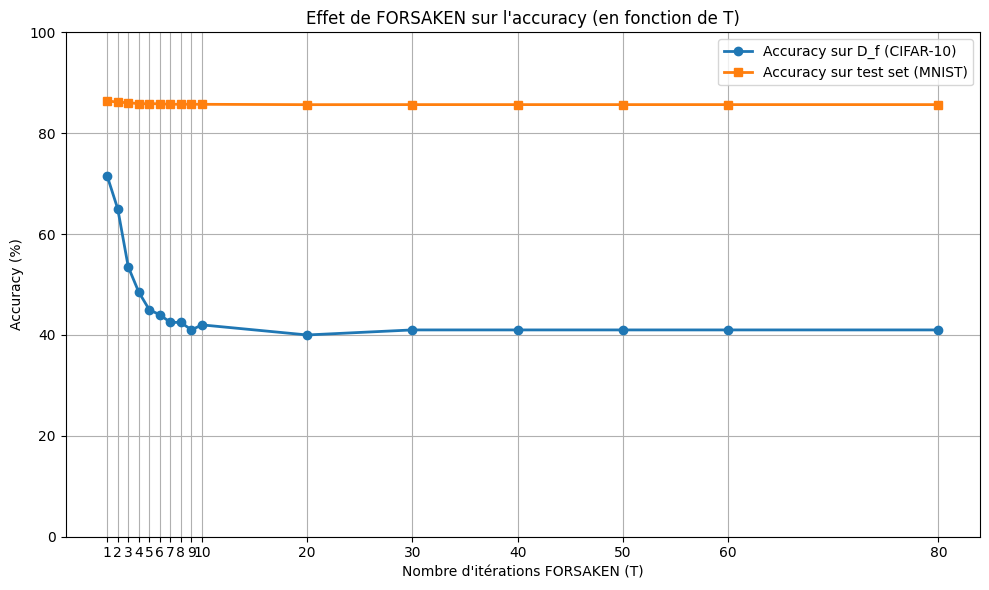

In [55]:
plot_forsaken_vs_accuracy(T_values, accuracies_forget, accuracies_test)